Notebook для практики по дисциплине "Методы машинного обучения"
Выполнили студенты:
- Баймухамедов Рафаэль Русланович
- Аршин Александр Дмитриевич
- Пасечный Леонид Витальевич

Преподаватель
- Петруша Полина Георгиевна

Импортируем и установим все необходимые для работы данного блокнота библиотеки

In [91]:
# Установка внешних библиотек
!pip install --upgrade pyvis
!pip install -U sentence-transformers

# Стандартная библиотека Python
import csv
import json
import math
import os
import sys
import subprocess
import colorsys
import re
from collections import Counter, defaultdict
from io import StringIO
from itertools import combinations
from pathlib import Path
import pathlib
from urllib.parse import urlencode

# Сторонние библиотеки
import requests
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import seaborn as sns
from scipy.stats import pearsonr
import networkx as nx
from scipy.sparse import issparse, hstack as sparse_hstack
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics.pairwise import cosine_similarity
import pyvis
from pyvis.network import Network
from jinja2 import Environment, FileSystemLoader
from tabulate import tabulate

Настроим pandas

In [92]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

Напишем некоторые вспомогательные функции

Функция для скачивания файлов с Яндекс.Диска

In [93]:
def load_from_yandex(public_key, file_type='auto', filename=None):
    base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'
    final_url = base_url + urlencode(dict(public_key=public_key))

    # Получаем ссылку для скачивания
    response = requests.get(final_url)
    response.raise_for_status()
    download_url = response.json()['href']

    # Скачиваем файл
    file_response = requests.get(download_url)
    file_response.raise_for_status()

    # При необходимости сохраняем сырые данные в файл
    if filename is not None:
        with open(filename, 'wb') as f:
            f.write(file_response.content)

    # Определяем тип файла
    if file_type == 'auto':
        content_type = file_response.headers.get('content-type', '')
        if 'text' in content_type or download_url.endswith(('.txt', '.csv')):
            file_type = 'text'
        elif download_url.endswith(('.xlsx', '.xls')):
            file_type = 'excel'
        else:
            file_type = 'binary'

    # Обрабатываем в зависимости от типа
    if file_type == 'text':
        content = file_response.content.decode('utf-8')
        corrections = {}
        for line in content.split('\n'):
            if ':' in line:
                name, value = line.split(':', 1)
                corrections[name.strip()] = int(value.strip())
        return corrections
    else:
        # Для excel и binary возвращаем бинарные данные
        return file_response.content

Функцию, выводящая суммарную информацию о датафрейме

In [94]:
def print_info(df):
    analysis = []

    for col in df.columns:
        dtype = df[col].dtype
        unique_count = df[col].nunique()
        missing_pct = (df[col].isna().sum() / len(df) * 100).round(2)

        unique_values = df[col].dropna().unique()
        if len(unique_values) <= 5:
            unique_display = list(unique_values)
        else:
            unique_display = ">5 unique values"

        analysis.append({
            'столбец': col,
            'тип': str(dtype),
            'уникальных': unique_count,
            'пропущено %': f"{missing_pct}%",
            'уникальные значения': unique_display
        })

    result_df = pd.DataFrame(analysis)
    print(tabulate(result_df, headers='keys', tablefmt='grid', showindex=False))

Функция преобразовангия CSV в словарь

In [95]:
def csv_to_dict(csv_content, sep=',', key_index=0, value_index=1):
    if isinstance(csv_content, bytes):
        text = csv_content.decode('utf-8-sig')
    else:
        text = str(csv_content)

    dict = {}
    reader = csv.reader(StringIO(text), delimiter=sep, quotechar='"')

    for row in reader:
        if len(row) <= max(key_index, value_index):
            continue

        key = row[key_index].strip()
        value = row[value_index].strip()

        if key and value:
            dict[key] = value

    return dict

Функция для замены в датафрейме в числовом столбце значения по ключу на значение из словаря

In [96]:
def apply_scalar_corrections(df, mapping, key_column, target_column):
    for key, value in mapping.items():
        mask = df[key_column] == key
        df.loc[mask, target_column] = value

Функция для замены в датафрейме в столбце с списком одного из значений по ключу на значение из словаря

In [97]:
def apply_str_list_corrections(df, mapping, target_column, sep=','):
    def replace(value):
        if pd.isna(value):
            return value

        parts = [p.strip() for p in str(value).split(sep)]
        parts = [mapping.get(p, p) for p in parts if p]

        return f'{sep} '.join(parts) if parts else ''

    df[target_column] = df[target_column].apply(replace)

Функция для замены значения из списка в строке столбца на заданное значение.

In [98]:
def replace_exact(df, col, variants, target):
    df.loc[df[col].isin(variants), col] = target

Скачаем датасет и файлы (патчи), корректирующие количество единиц за прием, приемов в день и названия ингредиентов

In [99]:
DATASET_URL = 'https://disk.yandex.ru/d/V1sJpR-SUJ_b8A'
DATASET_NAME = 'dataset.xlsx'
DOSAGE_UNITS_URL = 'https://disk.yandex.ru/d/qpV_VdGo10g6_w'
DOSAGE_TIMES_URL = 'https://disk.yandex.ru/d/SNu6f9k2CXLDLA'
CORRECT_NAME_OF_INGREDIENTS_URL = 'https://disk.yandex.ru/d/ZaIEDuJ0ew-SOw'

_ = load_from_yandex(DATASET_URL, filename=DATASET_NAME)
dosage_units_csv = load_from_yandex(DOSAGE_UNITS_URL, filename='dosage_units.csv')
dosage_times_csv = load_from_yandex(DOSAGE_TIMES_URL, filename='dosage_units.csv')
correct_names_of_ingredients_csv = load_from_yandex(CORRECT_NAME_OF_INGREDIENTS_URL, ',', filename='correct_names_of_ingredients.csv')

Преобразуем скачанные патчи в соответствующие словари

In [100]:
dosage_units_dict = csv_to_dict(dosage_units_csv, sep=':')
dosage_times_dict = csv_to_dict(dosage_times_csv, sep=':')
correct_names_of_ingredients_dict = csv_to_dict(correct_names_of_ingredients_csv, sep=',')

Прочитаем в датафрейм наш файл

In [101]:
df = pd.read_excel(DATASET_NAME, sheet_name=0, header=[0,1])
print("Данные загружены в df")

Данные загружены в df


# Предобработка данных

Посмотрим на датафрейм до какой-либо предобработки данных

In [102]:
df.head()

Unnamed: 0_level_0  \
                                                                                                                            Наименование   
0                                                    биологически активная добавка к пище "ВитаФин" ("VitaFin") (таблетки массой 700 мг)   
1                                               биологически активная добавка к пище "Гепаплант" ("Hepaplant") (таблетки массой 1000 мг)   
2  биологически активная добавка к пище "Фемибион ® Наталкер I" ("Femibion® Natalcare I") (таблетки массой 609 мг±3% покрытые оболочкой)   
3                                 биологически активная добавка к пище "Неогален (Neogalen). СЛИМ КОД. Комплекс" (капсулы массой 500 мг)   
4                                                                   биологически активная добавка к пище "КРЕСТИНОЛ" (капсулы по 350 мг)   

                                                                                                                                                                                                                                                                                                                      Unnamed: 1_level_0  \
                                                                                                                                                                                                                                                                                                                            Изготовитель   
0                                                                                                                                                                                                                                                    Ханкинтатукку Оу" ("Hankintatukku Oy"), Lehtolankatu 18, 03600 Karkkila (Финляндия)   
1                                                                                                                                                                                                                                                    Ханкинтатукку Оу" ("Hankintatukku Oy"), Lehtolankatu 18, 03600 Karkkila (Финляндия)   
2  "Мерк КгаА энд Ко Верк Шпитталь", Хёссельгассе 20, А- 9800 Шпитталь/Драу, Австрия или "Никомед Фарма Сп. з.о.о.", Ал. Иерозолимские 146 А, 02-305, Варшава, Польша под контролем "Мерк Зельбстмедикацион ГмбХ, Pёсслерштрассе, 96, 64293 Дармштадт ("Merck Selbstmedikation GmbH", Rosslerstrasse 96, 64293 Darmstadt) (ФРГ) Германия   
3                                                                                                                                  продукция изготовлена ООО "КоролёвФарм", 121609, г. Москва, ул. Крылатские холмы, д.1, кв.422 (адрес производства: 141070, Московская область, г.Королёв, ул. Пионерская, д.4) (Российская Федерация)   
4                                                                                                                                                                                                                                                   ЗАО "Пекталь", 193019, г. Санкт-Петербург, ул. Бехтерева, д.1 (Российская Федерация)   

                              Unnamed: 2_level_0  \
                      Номер свидетельства и дата   
0   RU.77.99.11.003.Е.000894.09.10 от 10.09.2010   
1   RU.77.99.11.003.Е.000895.09.10 от 10.09.2010   
2  RU.77.99.11.003.Е.000886.09.10 от 10.09.2010    
3   RU.77.99.11.003.Е.001040.09.10 от 14.09.2010   
4   RU.77.99.11.003.Е.001573.10.10 от 05.10.2010   

                                                                                                                                                                                                                                                                                                                                                                                                                                                               

Соединим заголовки первого и второго уровня вместе. Также уберем пробелы между словами в столбцах, заменив их на "_" и приведем названия столбцов к нижнему регистру.

In [103]:
def clean(s):
    if s is None:
        return ""
    s = str(s).replace("\n", " ").replace("\xa0", " ").strip()
    return re.sub(r"\s+", " ", s)

flat = []
for top, sub in df.columns:
    top, sub = clean(top), clean(sub)
    name = sub if (not top or top.lower().startswith("unnamed")) else f"{top}__{sub}" if sub else top
    name = name.replace("ё", "е")
    name = re.sub(r"\s+", "_", name)
    name = re.sub(r"[\\/:;,\"'()]+", "_", name)
    name = re.sub(r"_+", "_", name).strip("_")
    name = name.lower()
    flat.append(name)

df.columns = flat

Переименуем некоторые столбцы

In [104]:
to_rename = {
    "пищевые_вещества_макро-_и_микроэлементы": "пищевые_вещества_макро_и_микроэлементы",
    "минеральные_и_минерало-органические_природные_субстанции_цеолиты_гуминовые_кислоты":"минеральные_и_минерало_органические_природные_субстанции_цеолиты_и_гуминовые_кислоты",
    "система_органов_костно-мышечная_сиситема": "система_органов_костно_мышечная_система",
    "система_органов_форма_выпуска":"форма_выпуска",
    "система_органов_продолжительность_приема":"продолжительность_приема",
    "система_органов_сырье_растительное_животное_биологическое":"сырье",
    "система_органов_сердечно-сосудистая_система":"система_органов_сердечно_сосудистая_система",
    "система_органов_происхождение_природное_синтетическое":"происхождение_природное_синтетическое"
}
df = df.rename(columns=to_rename)

Теперь заменим:
- орфографические ошибки
- продолжительность приёма в значение месяца по максимальному значению
- срок годности в месяцы
- возраст детей в месяцы
- столбцы с двумя уникальными значениями в бинарные

In [105]:
pairs = [
    # Исправление орфографических ошибок
    ["пищевые_вещества_белки_пептиды_аминокислоты_нуклеиновые_кислоты", ["аминоксилоты"], "аминокислоты"],
    ["минорные_компоненты_растений_алкалоиды", ["алкалод", "алкалоид"], "алкалоиды"],
    ["пищевые_вещества_углеводы_и_продукты_их_переработки", ["полисахарид", "полисахарилы", "полисхариды"], "полисахариды"],
    ["минорные_компоненты_растений_гидроксикоричные_кислоты", ["гидрокор"], "гидроксикор"],
    ["минорные_компоненты_растений_ферменты", ["фермент"], "ферменты"],
    ["минеральные_и_минерало_органические_природные_субстанции_цеолиты_и_гуминовые_кислоты", ["цеолит"], "цеолиты"],
    ["система_органов_для_беременных_кормящих_и_планирующих_беременность", ["берем"], "беременные"],
    ["система_органов_костно_мышечная_система", ["суст", "суств"], "суставы"],
    ["система_органов_нервная_система", ["невр", "неврная", "нерврная", "нерв"], "нервная"],
    ["система_органов_иммунная_система", ["имм", "имммун", "иммун"], "иммунитет"],
    ["система_органов_дерматологические_бад", ["коэа"], "кожа"],
    ["система_органов_сердечно_сосудистая_система", ["серд"], "сердце"],
    ["система_органов_противопаразитарные_бад", ["паразит"], "паразиты"],
    ["система_органов_дыхательная_система", ["легк"], "легкие"],
    ["система_органов_противомикробные_бад", ["бакт", "бактер"], "бактерия"],
    ["система_органов_противомикробные_бад", ["вир"], "вирус"],
    ["система_органов_противомикробные_бад", ["вир"], "вирус"],
    ["система_органов_противомикробные_бад", ["грию"], "гриб"],

    # Переведем продолжительность приема в месяцы
    ["продолжительность_приема", ["1 месяц и менее", "постоянно"], "1"],
    ["продолжительность_приема", ["1-2 месяца"], "2"],
    ["продолжительность_приема", ["3 месяца"], "3"],
    ["продолжительность_приема", ["6 месяцев"], "6"],
    ["продолжительность_приема", ["9 месяцев"], "9"],
    ["продолжительность_приема", ["не указано"], pd.NA],

    # Переведем срок годности в месяцы
    ["срок_годности", ["1 год"], "12"],
    ["срок_годности", ["1 год, 2 месяца"], "14"],
    ["срок_годности", ["1,5 года"], "18"],
    ["срок_годности", ["15 суток"], "0.5"],
    ["срок_годности", ["1 год, 2 года", "2 года", "2 года, 1 год", "2 года, 1,5 года"], "24"],
    ["срок_годности", ["2,5 года"], "30"],
    ["срок_годности", ["3 года"], "36"],
    ["срок_годности", ["3,5 года"], "42"],
    ["срок_годности", ["4 года"], "48"],
    ["срок_годности", ["5 лет"], "60"],
    ["срок_годности", ["1 месяц"], "1"],
    ["срок_годности", ["2 месяца"], "2"],
    ["срок_годности", ["2,5 месяца"], "2.5"],
    ["срок_годности", ["3 месяца"], "3"],
    ["срок_годности", ["6 месяцев"], "6"],
    ["срок_годности", ["8 месяцев"], "8"],
    ["срок_годности", ["11 месяцев"], "11"],
    ["срок_годности", ["14 месяцев"], "14"],
    ["срок_годности", ["19 месяцев"], "19"],
    ["срок_годности", ["20 месяцев"], "20"],
    ["срок_годности", ["21 месяц"], "21"],
    ["срок_годности", ["25 месяцев"], "25"],
    ["срок_годности", ["28 месяцев"], "28"],
    ["срок_годности", ["32 месяца"], "32"],

    # Переведем возраст детей в месяцы
    ["группа_населения_возраст_детей", ["с рождения"], "0"],
    ["группа_населения_возраст_детей", ["от 3 месяцев"], "3"],
    ["группа_населения_возраст_детей", ["от 1 года"], "12"],
    ["группа_населения_возраст_детей", ["от 1,5 лет"], "24"],
    ["группа_населения_возраст_детей", ["от 3 лет"], "36"],
    ["группа_населения_возраст_детей", ["от 4 лет"], "48"],
    ["группа_населения_возраст_детей", ["от 5 лет"], "60"],
    ["группа_населения_возраст_детей", ["от 7 лет"], "84"],
    ["группа_населения_возраст_детей", ["от 11 лет"], "132"],
    ["группа_населения_возраст_детей", ["от 12 лет"], "144"],
    ["группа_населения_возраст_детей", ["от 14 лет"], "168"],

    # Преобразуем форму выпуска БАДа в новые значения
    ["форма_выпуска", ["таблетки","капсулы","пастилки","пилюли","драже","леденцы","плитки","таблетки, капсулы", "капсулы, пилюли","таблетки, капсулы, пастилки","таблетки, пилюли","капсулы, пастилки"], "твердое"],
    ["форма_выпуска", ["порошок","гранулы","порошок, гранулы"], "сыпучее"],
    ["форма_выпуска", ["гели","пасты","желе"], "полутвердое"],
    ["форма_выпуска", ["растворы","суспензия"], "жидкое"],
    ["форма_выпуска", ["сбор"], "сборы"],
    ["форма_выпуска", ["таблетки, порошок","таблетки, капсулы, порошок","капсулы, порошок","капсулы, порошок ", "таблетки, порошок, капсулы, гранулы"], "твердое, сыпучее"],
    ["форма_выпуска", ["капсулы, растворы","таблетки, капсулы, растворы","таблетки, растворы"], "твердое, жидкое"],
    ["форма_выпуска", ["таблетки, капсулы, сбор","капсулы, сбор"], "твердое, сборы"],
    ["форма_выпуска", ["капсулы, порошок, пасты"], "твердое, сыпучее, полутвердое"],
    ["форма_выпуска", ["раствор, сбор"], "жидкое, сборы"],

    # Преобразуем некоторые столбцы для последующей бинаризации
    ["происхождение", ["иностранное"], pd.NA]
]

for i in range(len(pairs)):
    replace_exact(df, pairs[i][0],pairs[i][1], pairs[i][2])

Создадим новые столбцы:
- "рекомендации_по_применению"
- "количество_единиц_на_прием"
- "количество_приемов_в_день"
- "ингредиент_описание"
- "ингредиент_кир"
- "ингредиент_лат"
- "биологически_активные_вещества"
- "системы_органов"
- "группа_населения"
- "суммарное_количество_единиц_за_период" = (количество единиц на приеме * количество приемов в день * продолжительность приема) (после привдения столбцов к неободимому типу)


In [106]:
df['рекомендации_по_применению'] = pd.NA
df["количество_единиц_на_прием"] = pd.NA
df["количество_приемов_в_день"] = pd.NA
df["суммарное_количество_единиц_за_период"] = pd.NA
df["ингредиент_описание"] = pd.NA
df["ингредиент_кир"] = pd.NA
df["ингредиент_лат"] = pd.NA
df["биологически_активные_вещества"] = pd.NA
df["системы_органов"] = pd.NA
df["группа_населения"] = pd.NA

Теперь перейдем к заполнению столбцов

Информацию для столбца "рекомендации_по_применению" берем из столбца "этикетка", а затем очищаем взятую оттуда информацию

In [107]:
dot = 0

for row in range(len(df)):
    string = str(df.at[row, 'этикетка'])
    value_1 = ""

    dot = string.find(".")+1
    second_dot_index = string.find(".", dot)

    if second_dot_index != -1:
        str_for_et = string[second_dot_index+1::].strip()
    else:
        str_for_et = string

    if "Рекомендации по применению" not in string:
        df.at[row, 'рекомендации_по_применению'] = None

    else:
        start_index = string.find("Рекомендации по применению")
        current_string = string[start_index:]
        duration_index = current_string.find("Продолжительность")

        if duration_index != -1:
            end_index = start_index + duration_index
            value_1 = string[start_index:end_index].strip()

            if value_1.endswith((':',' ','.')):
                value_1 = value_1[:-1].strip()

        else:
            index = 0
            while True:
                if index + 1 >= len(current_string):
                    value_1 = current_string.strip()
                    break

                if current_string[index+1] != ".":
                    index += 1
                else:
                    value_1 = string[start_index : start_index + index + 2].strip()
                    break

    df.at[row, 'рекомендации_по_применению'] = value_1
    df.at[row, 'этикетка'] = str_for_et

Информацию для столбцов:
- "количество_единиц_на_прием"
- "количество_приемов_в_день"

возьмем из "рекомендации_по_применению".

In [108]:
re_po_range = re.compile(r'по\s*(\d+)\s*-\s*(\d+)', flags=re.IGNORECASE)
re_po_single = re.compile(r'по\s*(\d+)(?!\s*-\s*\d+)', flags=re.IGNORECASE)
re_grams = re.compile(r'\((\d+)\s*г\)', flags=re.IGNORECASE)
re_times_range = re.compile(r'(\d+)\s*-\s*(\d+)\s*раз', flags=re.IGNORECASE)
re_times_single = re.compile(r'(\d+)\s*раз', flags=re.IGNORECASE)
re_grams_inline = re.compile(r'\b(\d+)\s*(?:г\b|грамм\w*)', flags=re.IGNORECASE)
re_ml = re.compile(r'\b(\d+)\s*мл\b(?!\s*питьевой воды)', flags=re.IGNORECASE)

for i in range(len(df)):
    string_raw = str(df.at[i, 'рекомендации_по_применению'])
    string = string_raw.lower()
    units = np.nan
    times = np.nan

    # количество_единиц_на_прием
    m = re_po_range.search(string)
    if m:
        units = int(m.group(2))
    else:
        m = re_po_single.search(string)
        if m:
            units = int(m.group(1))
        else:
            if 'пакет' in string:
                idx = string.find('пакет')
                left_window = string[max(0, idx-12):idx]
                m = re.search(r'(\d+)\s*-\s*(\d+)', left_window)
                if m:
                    units = int(m.group(2))
                else:
                    m = re.search(r'(\d+)', left_window)
                    if m:
                        units = int(m.group(1))
            if np.isnan(units):
                m = re_grams.search(string)
                if m:
                    units = int(m.group(1))
            if np.isnan(units):
                m = re_grams_inline.search(string)
                if m:
                    units = int(m.group(1))
            if np.isnan(units):
                m = re_ml.search(string)
                if m:
                    units = int(m.group(1))
    df.at[i, 'количество_единиц_на_прием'] = units

    # количество_приемов_в_день
    times = 1
    m = re_times_range.search(string)
    if m:
        times = int(m.group(2))
    else:
        m = re_times_single.search(string)
        if m:
            times = int(m.group(1))
    df.at[i, 'количество_приемов_в_день'] = times

Применим патчи к получившемся значениям в столбцах

In [109]:
apply_scalar_corrections(df, dosage_units_dict, "наименование", "количество_единиц_на_прием")
apply_scalar_corrections(df, dosage_times_dict, "наименование", "количество_приемов_в_день")

Информацию для столбцов:
- "ингредиент_описание"
- "ингредиент_рус"
- "ингредиент_лат"

возьмем из столбца "сырье"

Функция для парсинга строки с сырьем на отдельные ингредиенты (если много ингредиентов через запятую)

In [110]:
# Парсим строку с сырьем
def parse_ingredient_string(raw_string):
  if pd.isna(raw_string) or not raw_string.strip():
    return []

  ingredients = []
  current = []
  bracket_count = 0
  quote_count = 0

  for char in raw_string:
    if char == '(':
      bracket_count += 1
    elif char == ')':
      bracket_count -= 1
    elif char == '"':
      quote_count = 1 - quote_count

    if char == ',' and bracket_count == 0 and quote_count == 0:
      ingredient_str = ''.join(current).strip()
      if ingredient_str:
        ingredients.append(ingredient_str)
      current = []
    else:
      current.append(char)

  if current:
    ingredient_str = ''.join(current).strip()
    if ingredient_str:
      ingredients.append(ingredient_str)

  return ingredients

Функция точно отличающая название на латинице или кириллице

In [111]:
def detect_language(text):
    cyrillic_count = len(re.findall(r'[а-яА-Я]', text))
    latin_count = len(re.findall(r'[a-zA-Z]', text))

    if cyrillic_count > latin_count:
        return 'cyrillic'
    elif latin_count > cyrillic_count:
        return 'latin'
    else:
        # Если равное количество символов или оба нуля, используем дополнительные признаки
        if re.search(r'[а-яА-Я]', text):
            return 'cyrillic'
        elif re.search(r'[a-zA-Z]', text):
            return 'latin'
        return 'unknown'

Функция для парсинга строки с сырьем на отдельные ингредиенты(если много ингредиентов через запятую)

In [112]:
def parse_single_ingredient(ingredient):
    ingredient = str(ingredient).strip().lower()

    if ingredient in ['nan', 'None', '']:
        return (pd.NA, pd.NA, pd.NA)

    if '(' in ingredient and ')' not in ingredient:
        ingredient = ingredient + ')'
    pattern1 = r'^(.+?)\s*\(([^()]+?)\s*[–\-—]\s*([^()]+?)\)\s*\.?$'
    match1 = re.match(pattern1, ingredient)

    if 'содержит бактерии' in ingredient:
      return (ingredient, pd.NA, pd.NA)
    if match1:
        description = match1.group(1).strip()
        first_part = match1.group(2).strip()
        second_part = match1.group(3).strip()

        description = description.rstrip('.')
        first_part = first_part.rstrip('.').strip('–').strip()
        second_part = second_part.rstrip('.').strip('–').strip()

        # Определяем язык для каждой части
        lang_first = detect_language(first_part)
        lang_second = detect_language(second_part)

        if lang_first == 'cyrillic' and lang_second == 'latin':
            return (description, first_part, second_part)
        elif lang_first == 'latin' and lang_second == 'cyrillic':
            if bool(re.search(r'[a-zA-Z]', second_part)) and ingredient.count("-") == 2:
              first_part += "-" + second_part[:second_part.find("-")]
              second_part = second_part[second_part.find("-")+1:]
            return (description, second_part, first_part)

        return (description, second_part, first_part)

    pattern2 = r'^(.+?)\s*\(([^()]+?)\)\s*\.?$'
    match2 = re.match(pattern2, ingredient)

    if match2:
        description = match2.group(1).strip()
        content = match2.group(2).strip()

        has_latin = bool(re.search(r'[a-zA-Z]', content))
        has_cyrillic = bool(re.search(r'[а-яА-Я]', content))

        description = description.rstrip('.')
        content = content.rstrip('.').strip('–').strip()

        if has_latin and not has_cyrillic:
          return (description, pd.NA, content)
        elif has_cyrillic and not has_latin:
            return (description, content, pd.NA)
        else:
            return (description, content, pd.NA)

    ingredient = ingredient.rstrip('.')
    return (ingredient, pd.NA, pd.NA)

In [113]:
for row in range(len(df)):
    raw_value = df.at[row, "сырье"]

    if pd.isna(raw_value) or str(raw_value).strip() in ['', 'nan', 'None']:
        df.at[row, "ингредиент_описание"] = pd.NA
        df.at[row, "ингредиент_кир"] = pd.NA
        df.at[row, "ингредиент_лат"] = pd.NA
        continue

    string = str(raw_value).strip().lower()
    ingredients = parse_ingredient_string(string)

    if not ingredients:
        description, cyryllic, latin = parse_single_ingredient(string)
        df.at[row, "ингредиент_описание"] = description
        df.at[row, "ингредиент_кир"] = cyrillic
        df.at[row, "ингредиент_лат"] = latin

    else:
        description_list = []
        cyrillic_list = []
        latin_list = []

        for ingredient in ingredients:
            description, cyrillic, latin = parse_single_ingredient(ingredient)
            if description:
                description_list.append(description)
            if pd.notna(cyrillic):
                cyrillic_list.append(cyrillic)
            if pd.notna(latin):
                latin_list.append(latin)

        df.at[row, "ингредиент_описание"] = ", ".join(description_list) if description_list else pd.NA
        df.at[row, "ингредиент_кир"] = ", ".join(cyrillic_list) if cyrillic_list else pd.NA
        df.at[row, "ингредиент_лат"] = ", ".join(latin_list) if latin_list else pd.NA

Удалим строки, у которых природное происхождение, но отсутствуют данные о сырье

In [114]:
col_origin = "происхождение_природное_синтетическое"
col_raw    = "сырье"

mask_raw_na = df["сырье"].isna()
mask_synth = df["происхождение_природное_синтетическое"].astype("string").str.contains("синтетическое", case=False, na=False)
mask_to_drop = mask_raw_na & (~mask_synth)

maxi = int(mask_to_drop.sum())
print("Строк для удаления:", maxi)

df = df.drop(df.index[mask_to_drop])

Строк для удаления: 14


Функция для извлечения ингредиентов из строки описания

In [115]:
def extract_ingredients(description):
    if pd.isna(description) or description == "":
        return []

    # Удаляем содержимое в скобках
    description_clean = re.sub(r'\([^)]*\)', '', str(description)).lower()

    # Разделяем по запятым и очищаем от лишних пробелов
    ingredients = [ing.strip().lower() for ing in description_clean.split(',')]

    # Удаляем пустые строки и строки, содержащие только знаки препинания
    ingredients = [ing for ing in ingredients if ing and ing.strip()]

    return ingredients

Удаление дополнительных кавычек и точек

In [116]:
def clean_ingredient_name(ingredient):
    # Удаляем кавычки в начале и конце
    ingredient = re.sub(r'^["\']|["\']$', '', ingredient)
    # Удаляем точки в конце
    ingredient = re.sub(r'\.$', '', ingredient)
    # Удаляем лишние пробелы
    ingredient = ingredient.strip()
    return ingredient

Теперь применим патч к столбцу "ингредиент_описание"

In [117]:
apply_str_list_corrections(df, correct_names_of_ingredients_dict, "ингредиент_описание", ",")

Теперь заполним столбцы:
- "биологически_активные_вещества"
- "системы_органов"
- "группа_населения"

следующим образом
- Столбцы J-X исходного датасета -> "биологически_активные_вещества"
- Столбцы Y-AL исходного датасета -> "системы_органов"
- Столбцы AQ-AU исходного датасета -> "группа_населения"

In [118]:
bio_prefixes = (
    "пищевые_вещества_",
    "минорные_компоненты_растений_",
    "пробиотики_",
    "минеральные_и_минерало_органические_природные_субстанции_"
)

cols_bioactive = [c for c in df.columns if c.startswith(bio_prefixes)]
cols_systems_organs = [c for c in df.columns if c.startswith("система_органов")]
cols_population_groups = [c for c in df.columns if c.startswith("группа_населения")]

Функция для объединения столбцов

In [119]:
def build_multi_value_column(df, source_columns, target_column):
    def collect(row):
        values = []
        for col in source_columns:
            val = row[col]

            if isinstance(val, str) and val.strip():
                values.append(val.strip())

        if not values:
            return pd.NA

        seen = set()
        uniq = []
        for v in values:
            if v not in seen:
                seen.add(v)
                uniq.append(v)

        return ", ".join(uniq)

    df[target_column] = df.apply(collect, axis=1)



In [120]:
build_multi_value_column(df, source_columns=cols_bioactive, target_column="биологически_активные_вещества")
build_multi_value_column(df, source_columns=cols_systems_organs, target_column="системы_органов")
build_multi_value_column(df, source_columns=cols_population_groups, target_column="группа_населения")

Сейчас в столбце "количество_групп_компонентов" число больше трех помечено как "много". Считаем что это некорректно, поэтому пересчитаем по количеству биологически-активных веществ в столбце "биологически_активные_вещества"

In [121]:
def count_items(text, sep=','):
    if pd.isna(text):
        return 0
    parts = str(text).split(sep)
    return sum(1 for part in parts if part.strip())

df['количество_групп_компонентов'] = df['биологически_активные_вещества'].apply(count_items)

Преобразуем нестандартный бинарный столбец

In [122]:
mask = df["происхождение_природное_синтетическое"].astype("string").str.contains("Синтетическое", na=False)

df.loc[mask, "происхождение_природное_синтетическое"] = pd.NA

Преобразуем столбцы, которые возможно к бинарному виду и для этого напишем функцию, которая переводит по следующему правилу:
- 'NaN' или '' -> 0
- Любая другая строка -> 1

In [123]:
def to_binary(value):
    if pd.isna(value):
        return 0

    text = str(value).strip()
    if text == "" or text.lower() == "nan" or text == "0":
        return 0

    return 1

Перечислим столбцы, требующей стандартной бинаризации

In [124]:
binary_columns = [
    "происхождение",
    "происхождение_природное_синтетическое",
    "пищевые_вещества_витамины_витаминоподобные_вещества_и_коферменты",
    "пищевые_вещества_макро_и_микроэлементы",
    "пищевые_вещества_жиры_жироподобные_вещества_и_их_производные",
    "пищевые_вещества_белки_пептиды_аминокислоты_нуклеиновые_кислоты",
    "пищевые_вещества_углеводы_и_продукты_их_переработки",
    "минорные_компоненты_растений_фенольные_соединения",
    "минорные_компоненты_растений_алкалоиды",
    "пробиотики_в_монокультурах_и_ассоциациях_пробиотические_микроорганизмы",
    "минорные_компоненты_растений_сапонины",
    "минорные_компоненты_растений_терпеноиды",
    "минорные_компоненты_растений_естественные_метаболиты_и_стимуляторы_метаболизма",
    "минорные_компоненты_растений_гидроксикоричные_кислоты",
    "минорные_компоненты_растений_ферменты",
    "минорные_компоненты_растений_дубильные_вещества",
    "минеральные_и_минерало_органические_природные_субстанции_цеолиты_и_гуминовые_кислоты",
    "система_органов_для_беременных_кормящих_и_планирующих_беременность",
    "система_органов_костно_мышечная_система",
    "система_органов_нервная_система",
    "система_органов_иммунная_система",
    "система_органов_пищеварительный_тракт_и_обмен_веществ",
    "система_органов_мочеполовая_система",
    "система_органов_дерматологические_бад",
    "система_органов_органы_чувств",
    "система_органов_сердечно_сосудистая_система",
    "система_органов_противоопухолевые_бад",
    "система_органов_противопаразитарные_бад",
    "система_органов_дыхательная_система",
    "система_органов_кровь_и_система_кроветворения",
    "система_органов_противомикробные_бад",
    "группа_населения_предназначен_для_детей",
    "группа_населения_предназначен_для_взрослых",
    "группа_населения_пожилые",
]

Применим ко всем этим столбцам

In [125]:
for col in binary_columns:
    df[col] = df[col].apply(to_binary).astype("Int8")

In [126]:
df.head(10)

,наименование,изготовитель,номер_свидетельства_и_дата,этикетка,происхождение,противопоказания,срок_годности,год_регистрации,количество_групп_компонентов,пищевые_вещества_витамины_витаминоподобные_вещества_и_коферменты,пищевые_вещества_макро_и_микроэлементы,пищевые_вещества_жиры_жироподобные_вещества_и_их_производные,пищевые_вещества_белки_пептиды_аминокислоты_нуклеиновые_кислоты,минорные_компоненты_растений_фенольные_соединения,минорные_компоненты_растений_алкалоиды,пробиотики_в_монокультурах_и_ассоциациях_пробиотические_микроорганизмы,пищевые_вещества_углеводы_и_продукты_их_переработки,минорные_компоненты_растений_сапонины,минорные_компоненты_растений_терпеноиды,минорные_компоненты_растений_естественные_метаболиты_и_стимуляторы_метаболизма,минорные_компоненты_растений_гидроксикоричные_кислоты,минорные_компоненты_растений_ферменты,минорные_компоненты_растений_дубильные_вещества,минеральные_и_минерало_органические_природные_субстанции_цеолиты_и_гуминовые_кислоты,система_органов_для_беременных_кормящих_и_планирующих_беременность,система_органов_костно_мышечная_система,система_органов_нервная_система,система_органов_иммунная_система,система_органов_пищеварительный_тракт_и_обмен_веществ,система_органов_мочеполовая_система,система_органов_дерматологические_бад,система_органов_органы_чувств,система_органов_сердечно_сосудистая_система,система_органов_противоопухолевые_бад,система_органов_противопаразитарные_бад,система_органов_дыхательная_система,система_органов_кровь_и_система_кроветворения,система_органов_противомикробные_бад,форма_выпуска,продолжительность_приема,происхождение_природное_синтетическое,сырье,группа_населения_предназначен_для_детей,группа_населения_возраст_детей,группа_населения_предназначен_для_взрослых,группа_населения_пол,группа_населения_пожилые,рекомендации_по_применению,количество_единиц_на_прием,количество_приемов_в_день,суммарное_количество_единиц_за_период,ингредиент_описание,ингредиент_кир,ингредиент_лат,биологически_активные_вещества,системы_органов,группа_населения
0,"биологически активная добавка к пище ""ВитаФин"" (""VitaFin"") (таблетки массой 700 мг)","Ханкинтатукку Оу"" (""Hankintatukku Oy""), Lehtolankatu 18, 03600 Karkkila (Финляндия)",RU.77.99.11.003.Е.000894.09.10 от 10.09.2010,"При необходимости прием можно повторить. Противопоказания: индивидуальная непереносимость компонентов, беременность, кормление грудью. Перед применением рекомендуется проконсультироваться с врачом. Лицам с заболеваниями щитовидной микроэлементыы рекомендуется проконсультироваться с врачом-эндокринологом. Срок годности - 3 года. Хранить в сухом, недоступном для детей месте, при температуре не выше 25°С.",0,"индивидуальная непереносимость компонентов, беременность, кормление грудью",36,2010,3,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,твердое,2,1,"Экстракта зелёного чая (Camellia sinensis - Камелия китайская), экстракт кожицы винограда (Винный виноград - Vitis Vinifera",0,NaN,1,NaN,0,Рекомендации по применению: взрослым по 1-2 таблетки в день во время еды,2,1,<NA>,"экстракт зеленого чая, экстракт кожицы винограда","камелия китайская, винный виноград","camellia sinensis, vitis vinifera","вит, элементы, фенольн",иммунитет,взрослые
1,"биологически активная добавка к пище ""Гепаплант"" (""Hepaplant"") (таблетки массой 1000 мг)","Ханкинтатукку Оу"" (""Hankintatukku Oy""), Lehtolankatu 18, 03600 Karkkila (Финляндия)",RU.77.99.11.003.Е.000895.09.10 от 10.09.2010,"При необходимости прием можно повторить. Противопоказания: индивидуальная непереносимость компонентов, беременность, кормление грудью. Перед применением рекомендуется проконсультироваться с врачом. Срок годности - 3 года. Хранить в сухом, недоступном для детей месте, при температуре не выше 25°С.",0,"индивидуальная непереносимость компонентов, беременность, кормление грудью",36,2010,4,1,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,твердое,2,1,"Экстракта зелёного чая (Camellia sinensis - Камелия китайская), экстракт кожицы винограда (Винный виногр

Теперь изменим тип столбцов

In [127]:
num_cols = [
    "продолжительность_приема",
    "количество_единиц_на_прием",
    "количество_приемов_в_день",
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

df["суммарное_количество_единиц_за_период"] = (df["продолжительность_приема"] * df["количество_единиц_на_прием"] * df["количество_приемов_в_день"] * 30).astype("Int64")

df["срок_годности"] = df["срок_годности"].astype("Float64")
df["группа_населения_возраст_детей"] = df["группа_населения_возраст_детей"].astype("Float64")

# Визуализицаия (Матрицы корреляций и графы)

# Матрицы корреляций и Heatmaps

Посмотрим корреляцию числовых признаков

In [128]:
numeric_columns = df.select_dtypes(include=['int8', 'Int8', 'int64', 'Int64', 'float64', 'Float64']).columns
numeric_df = df[numeric_columns].copy()

correlation_pearson = numeric_df.corr(method='pearson') # linear data
correlation_spearman = numeric_df.corr(method='spearman') # unlinear data

Heatmap на основе корреляции

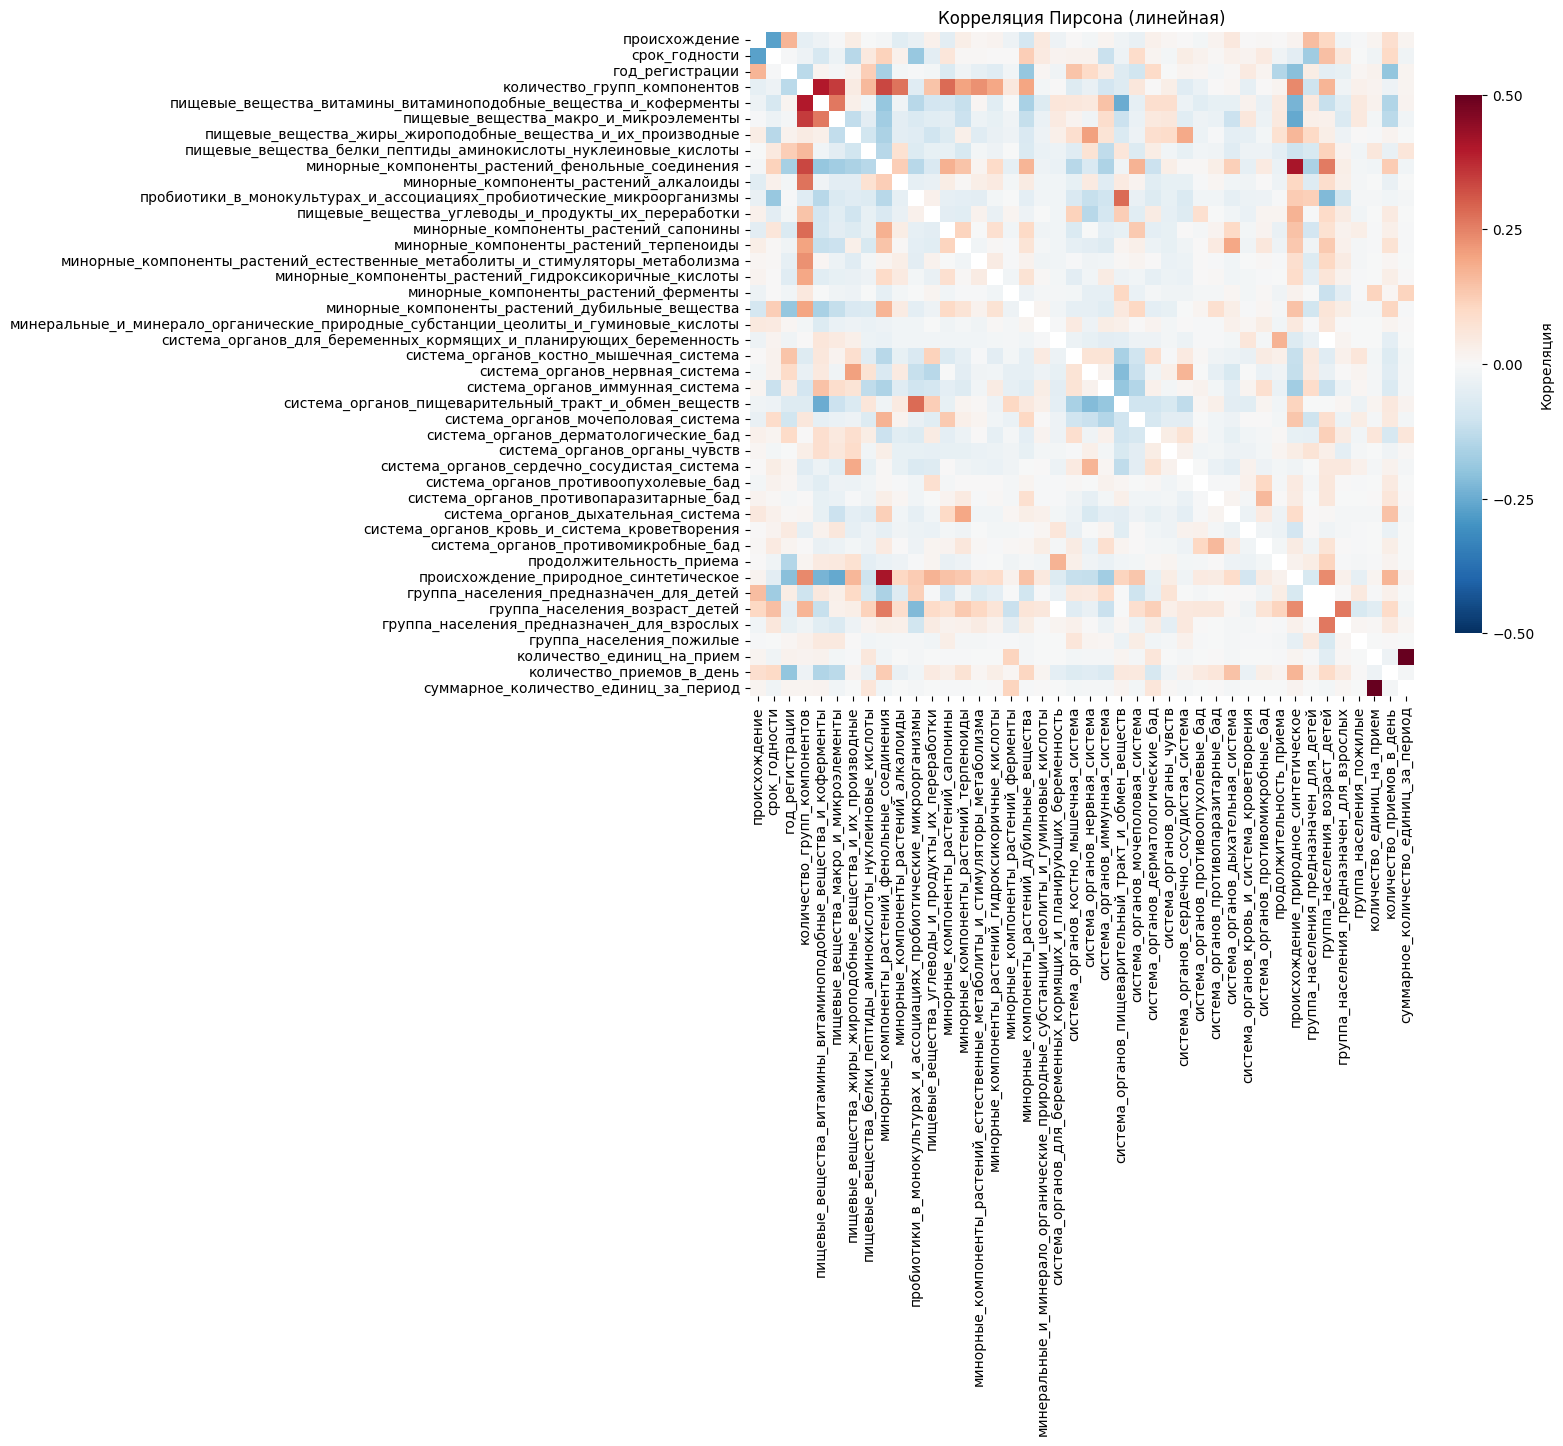

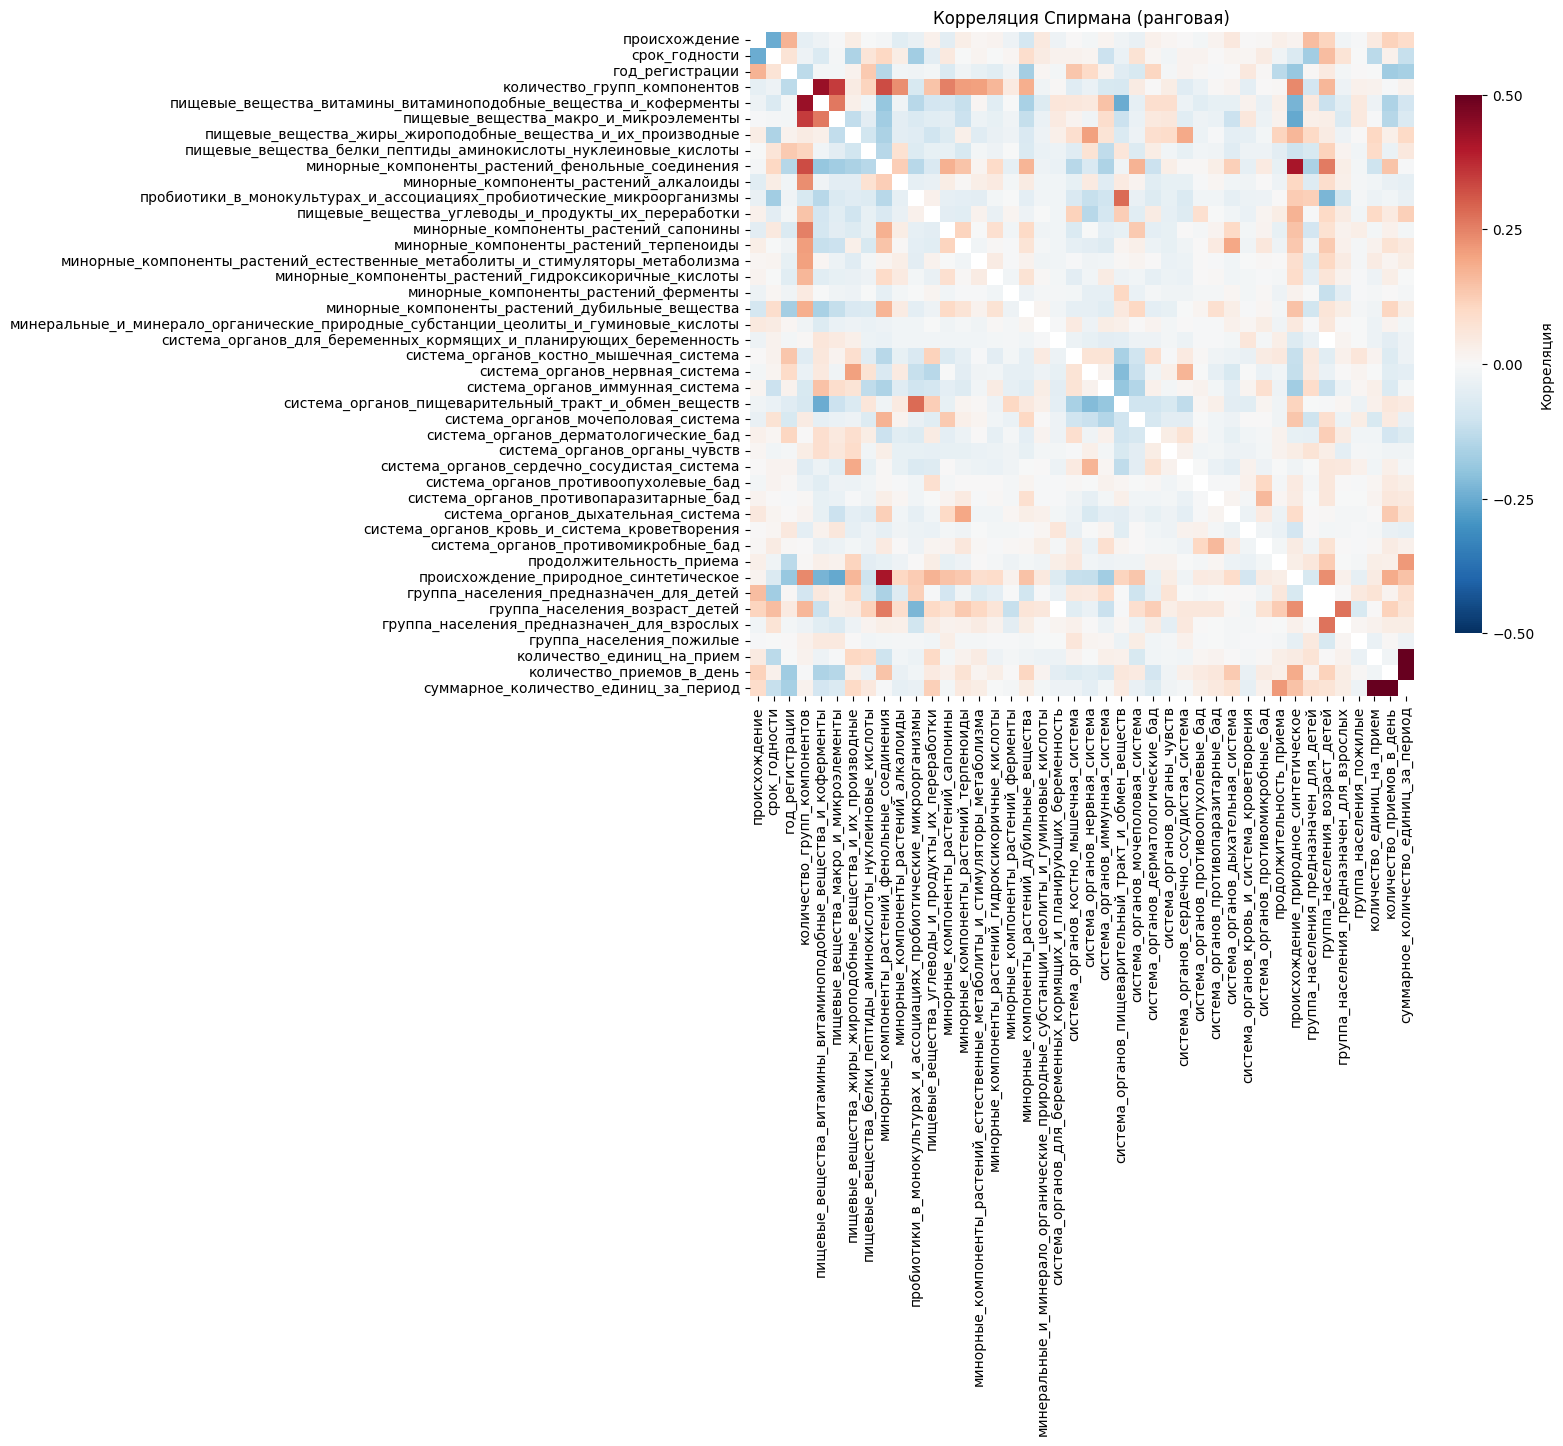

In [129]:
mask = np.eye(len(correlation_pearson), dtype=bool)

# Heatmap Пирсон
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_pearson,
            annot=False,
            mask=mask,
            cmap='RdBu_r',
            center=0,
            vmin=-0.5, vmax=0.5,
            square=True,
            cbar_kws={
                'label': 'Корреляция',
                'shrink': 0.8,
                'ticks': [-0.5, -0.25, 0, 0.25, 0.5]
            })
plt.title('Корреляция Пирсона (линейная)')
plt.tight_layout()
plt.show()
mask = np.eye(len(correlation_spearman), dtype=bool)

# Heatmap Спирман
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_spearman,
            annot=False,
            mask=mask,
            cmap='RdBu_r',
            center=0,
            vmin=-0.5, vmax=0.5,
            square=True,
            cbar_kws={
                'label': 'Корреляция',
                'shrink': 0.8,
                'ticks': [-0.5, -0.25, 0, 0.25, 0.5]
            })
plt.title('Корреляция Спирмана (ранговая)')
plt.tight_layout()
plt.show()

Выберем пары с самой высокой корреляцией по заданному порогу

In [130]:
threshold_for_corr_in_numeric_columns = 0.2

correlation_matrix = df[numeric_columns].corr()

strong_pairs = []
for i in range(len(correlation_matrix.columns)):
  for j in range(i+1, len(correlation_matrix.columns)):
    corr = correlation_matrix.iloc[i, j]
    if abs(corr) >= threshold_for_corr_in_numeric_columns:
      strong_pairs.append({
          'feature1': correlation_matrix.columns[i],
          'feature2': correlation_matrix.columns[j],
          'correlation': corr
      })

# Удаление бессмысленных пар корреляции
significant_pairs = sorted(strong_pairs, key=lambda x: abs(x['correlation']), reverse=True)

# Определяем бессмысленные пары как наборы
meaningless_sets = [
    {'группа_населения_возраст_детей', 'группа_населения_предназначен_для_взрослых'},
    {'количество_единиц_на_прием', 'суммарное_количество_единиц_за_период'}
]

# Фильтруем пары
significant_pairs = [
    pair for pair in significant_pairs
    if {pair['feature1'], pair['feature2']} not in meaningless_sets
]



Построим диаграмму рассеивания для получившехся пар

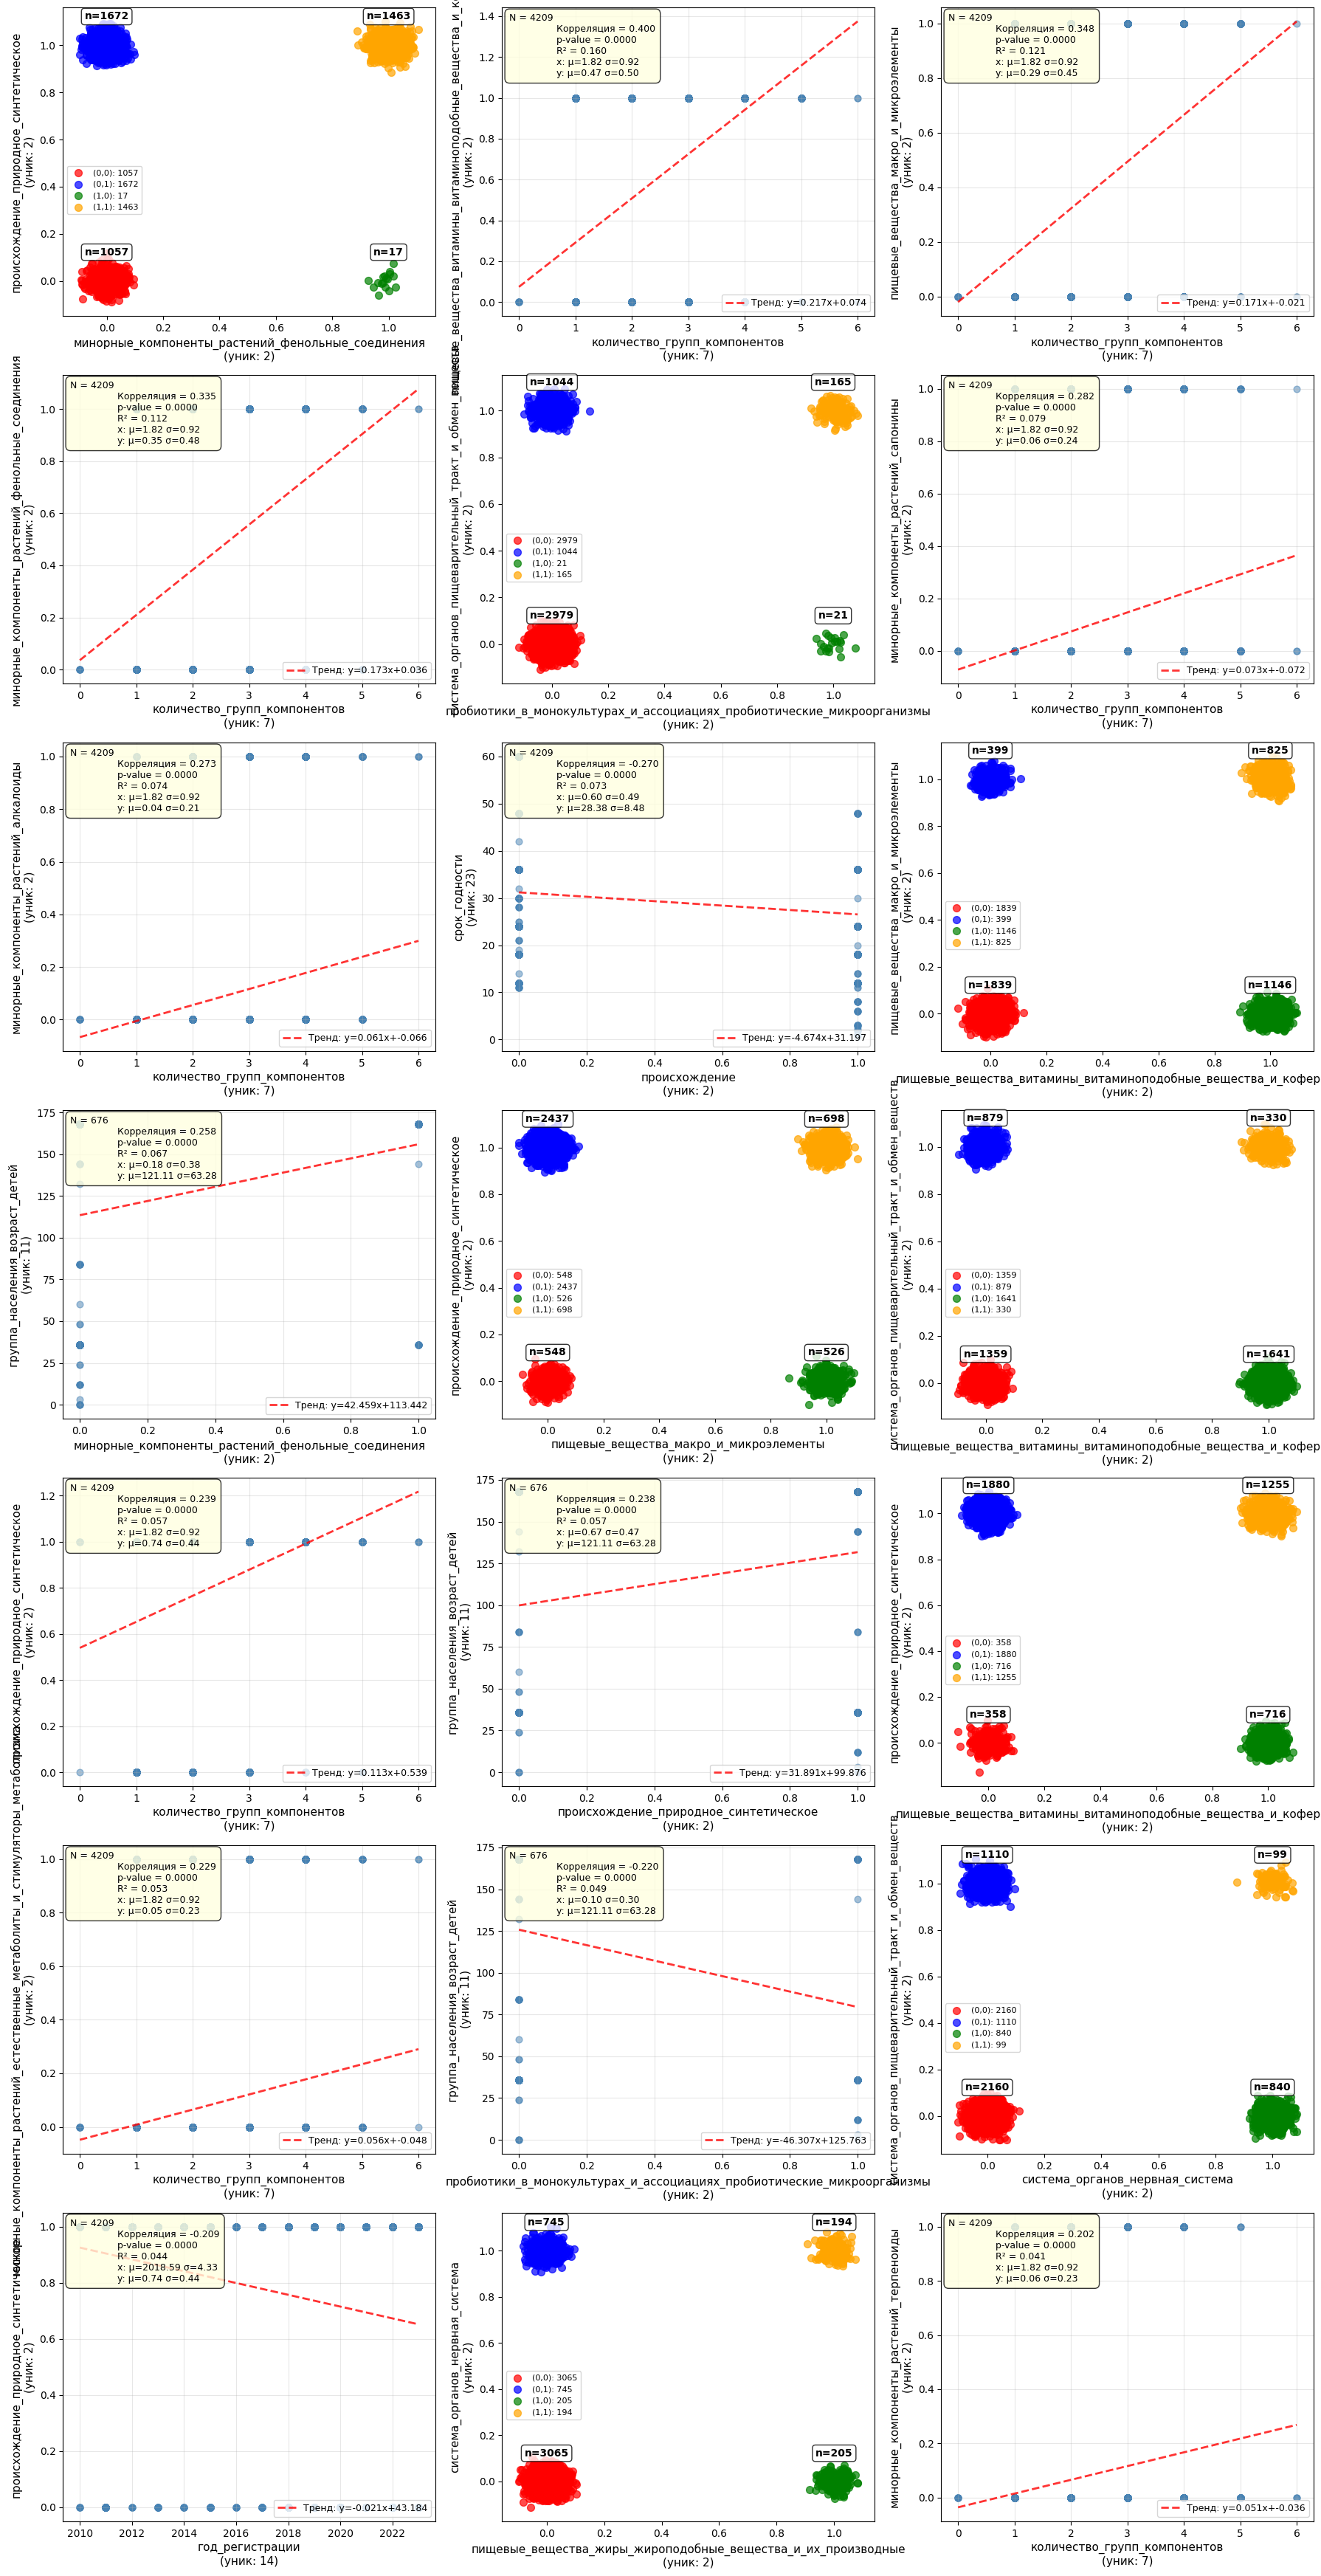

In [131]:
if significant_pairs:
    n_cols = 3
    n_rows = (len(significant_pairs) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))

    if n_rows * n_cols == 1:
        axes = [axes]
    else:
        axes = axes.ravel()

    # Цветовая палитра для кластеров
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']

    for idx, pair in enumerate(significant_pairs):
        if idx < len(axes):
            ax = axes[idx]
            feature1 = pair['feature1']
            feature2 = pair['feature2']
            corr_value = pair['correlation']

            # Данные для текущей пары (удаляем пропуски)
            data_pair = numeric_df[[feature1, feature2]].dropna()
            x_data = data_pair[feature1]
            y_data = data_pair[feature2]

            # Если оба признака бинарные
            if x_data.nunique() <= 2 and y_data.nunique() <= 2:
                # Создаем группы для каждого сочетания бинарных значений
                groups = data_pair.groupby([feature1, feature2]).size().reset_index(name='count')

                # Рисуем точки для каждой группы с разным цветом
                for i, (_, group) in enumerate(groups.iterrows()):
                    x_val = group[feature1]
                    y_val = group[feature2]
                    count = group['count']

                    # Добавляем jitter для разделения точек
                    jitter_x = np.random.normal(0, 0.03, count)
                    jitter_y = np.random.normal(0, 0.03, count)

                    ax.scatter(x_val + jitter_x, y_val + jitter_y,
                              alpha=0.7, s=50, color=colors[i % len(colors)],
                              label=f'({x_val},{y_val}): {count}')

                # Добавляем подписи количества для каждой группы
                for _, group in groups.iterrows():
                    x_val = group[feature1]
                    y_val = group[feature2]
                    count = group['count']

                    # Подписываем количество над кластером
                    ax.text(x_val, y_val + 0.1, f'n={count}',
                           ha='center', va='bottom', fontsize=10, fontweight='bold',
                           bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

                # Легенда
                ax.legend(loc='upper left', bbox_to_anchor=(0, 0.5), fontsize=8)

                # 6. Настройки осей
                ax.set_xlabel(f'{feature1}\n(уник: {x_data.nunique()})', fontsize=11)
                ax.set_ylabel(f'{feature2}\n(уник: {y_data.nunique()})', fontsize=11)

            else:
                scatter = ax.scatter(x_data, y_data, alpha=0.5, s=40, c='steelblue')

                # 2. Линия тренда
                if len(x_data) > 1:
                    z = np.polyfit(x_data, y_data, 1)
                    p = np.poly1d(z)
                    x_trend = np.linspace(x_data.min(), x_data.max(), 100)
                    ax.plot(x_trend, p(x_trend), "r--", linewidth=2, alpha=0.8,
                           label=f'Тренд: y={z[0]:.3f}x+{z[1]:.3f}')

                # 3. Вычисляем дополнительную статистику
                stats_text = f"""N = {len(data_pair)}
                Корреляция = {corr_value:.3f}
                p-value = {pearsonr(x_data, y_data)[1]:.4f}
                R² = {corr_value**2:.3f}
                x: μ={x_data.mean():.2f} σ={x_data.std():.2f}
                y: μ={y_data.mean():.2f} σ={y_data.std():.2f}"""

                # 4. Добавляем текстовый блок со статистикой
                ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
                       verticalalignment='top', bbox=dict(boxstyle="round,pad=0.5",
                       facecolor='lightyellow', alpha=0.8))

                # 6. Настройки осей
                ax.set_xlabel(f'{feature1}\n(уник: {x_data.nunique()})', fontsize=11)
                ax.set_ylabel(f'{feature2}\n(уник: {y_data.nunique()})', fontsize=11)

                # 7. Заголовок с информацией о типе связи
                if abs(corr_value) > 0.7:
                    strength = "ОЧЕНЬ СИЛЬНАЯ"
                elif abs(corr_value) > 0.5:
                    strength = "СИЛЬНАЯ"
                elif abs(corr_value) > 0.2:
                    strength = "УМЕРЕННАЯ"
                else:
                    strength = "СЛАБАЯ"

                direction = "ПОЛОЖИТЕЛЬНАЯ" if corr_value > 0 else "ОТРИЦАТЕЛЬНАЯ"

                # 8. Сетка
                ax.grid(True, alpha=0.3)

                # 9. Легенда
                ax.legend(loc='lower right', fontsize=9)

    # Скрываем пустые subplots
    for idx in range(len(significant_pairs), len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.show()

Построим матрицу корреляций для ингредиентов, встречающихся больше заданного значения раз

Проанализировано 52 ингредиентов


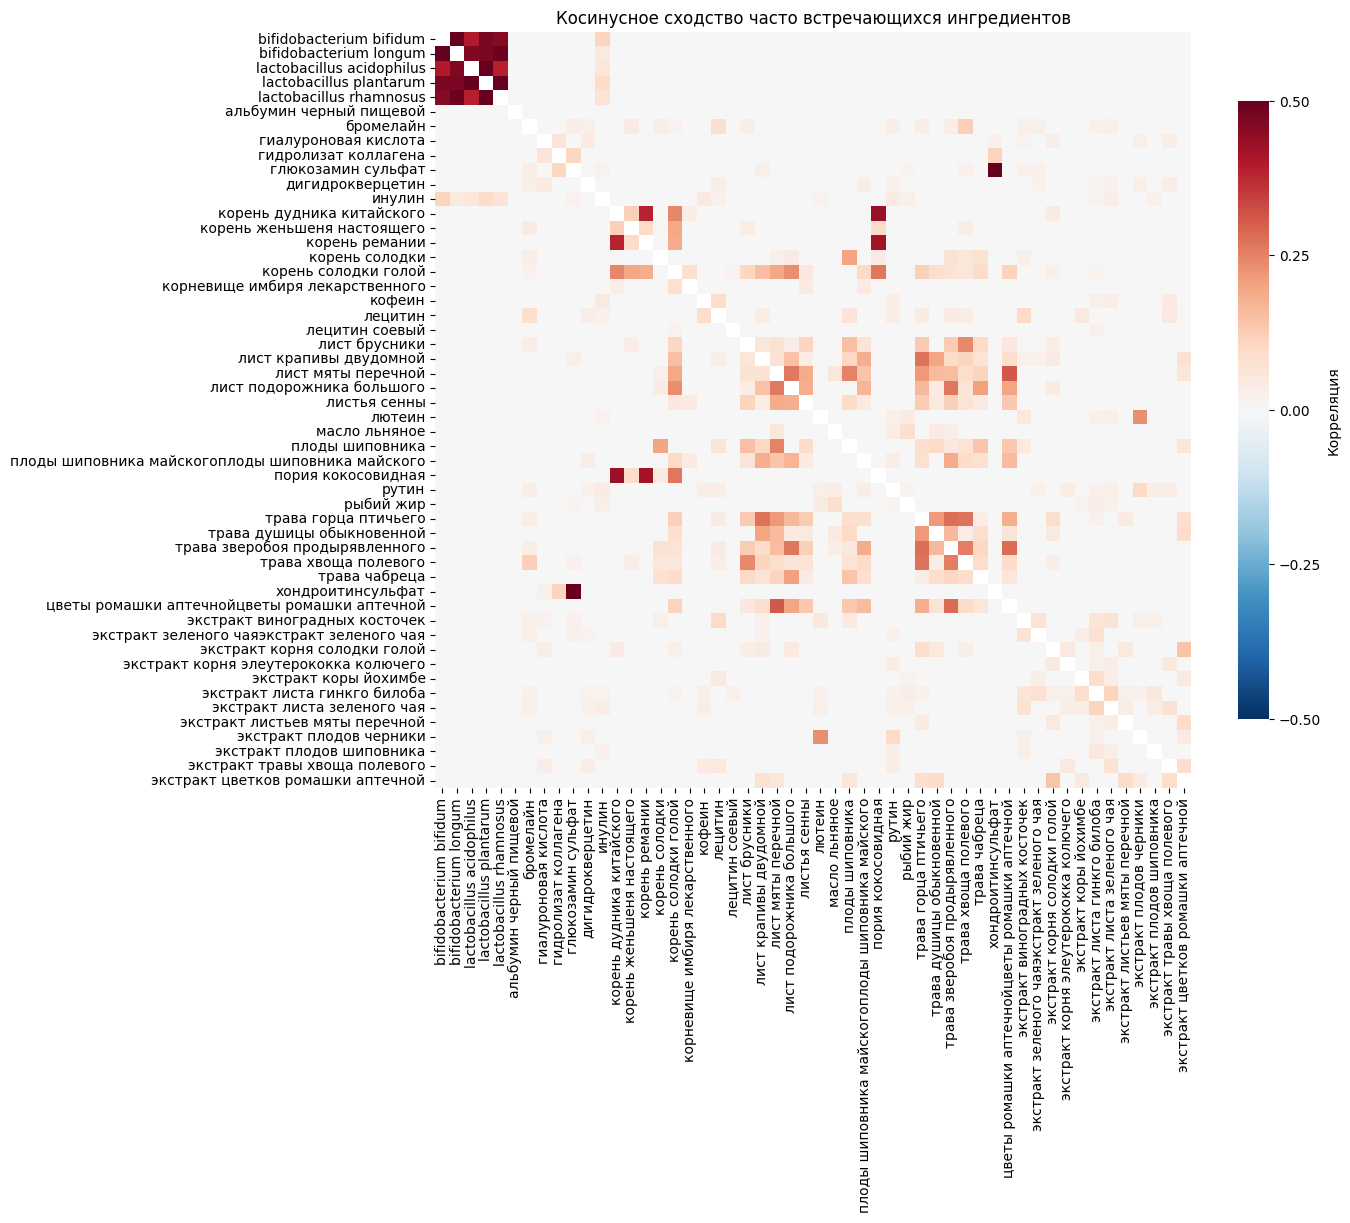

In [132]:
threshold_for_corr_in_ingredients = 20

def split_ingredients(text):
    if pd.isna(text):
        return []
    return [part.strip() for part in str(text).split(',') if part.strip()]

# 1. Получаем списки ингредиентов из столбца 'ингредиент_описание'
ingredient_lists = df['ингредиент_описание'].apply(split_ingredients)

# 2. One-hot матрица ингредиентов
mlb = MultiLabelBinarizer()
ingredient_matrix = mlb.fit_transform(ingredient_lists)
ingredient_df = pd.DataFrame(ingredient_matrix, columns=mlb.classes_)

# 3. Оставляем только часто встречающиеся ингредиенты (>= threshold_for_corr_in_ingredients раз)
frequent_ingredients = ingredient_df.columns[ingredient_df.sum() >= threshold_for_corr_in_ingredients]
filtered_df = ingredient_df[frequent_ingredients]

# 4. Матрица "сходства" ингредиентов по косинусной близости
corr_matrix = pd.DataFrame(
    cosine_similarity(filtered_df.T),
    index=frequent_ingredients,
    columns=frequent_ingredients
)

# 5. Визуализация
mask = np.eye(len(corr_matrix), dtype=bool)
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    cmap='RdBu_r',
    center=0,
    mask=mask,
    vmin=-0.5, vmax=0.5,
    square=True,
    cbar_kws={
        'label': 'Корреляция',
        'shrink': 0.8,
        'ticks': [-0.5, -0.25, 0, 0.25, 0.5]
    }
)
plt.title("Косинусное сходство часто встречающихся ингредиентов")
plt.tight_layout()

print(f"Проанализировано {len(frequent_ingredients)} ингредиентов")

In [133]:
df.to_csv("data.csv", index=False)

## Графы

Перейдем к построению графов. Начнём с графов двойной композиции.

В первом случае у нас:
- вершины - биологически активные вещества
- ребра - наличие БАД содержащих эти биологически активные вещества
- вес - количество БАД содержащих эти биологически активные вещества

Во втором случае у нас:
- вершины - растения
- ребра - наличие БАД содержащих эти растения
- вес - количество БАД содержащих эти растения

Напишем функцию, которая находит ребра и веса этих графов, функцию, которая разбирает строку в список элементов, а также функцию которая убирает значения меньше определенного в словаре

In [134]:
def parse_items(cell, sep=",", mapper=None):
    if pd.isna(cell):
        return []

    raw_items = [x.strip() for x in str(cell).split(sep)]

    items = []
    for x in raw_items:
        if not x:
            continue
        if mapper is not None:
            x = mapper(x)
        items.append(x)

    return sorted(set(items))

def count_pairs(df, col, sep=",", mapper=None):
    pair_counts = {}

    for cell in df[col]:
        items = parse_items(cell, sep=sep, mapper=mapper)
        if len(items) < 2:
            continue

        for a, b in combinations(items, 2):
            key = (a, b)
            pair_counts[key] = pair_counts.get(key, 0) + 1

    return pair_counts

def filter_dictionary_by_value(dict, threshold):
    filtered_dict = {
        key: value
        for key, value in dict.items()
        if value >= threshold
    }
    return filtered_dict

Поскольку нам важно, чтобы на графе были корректные и полнообъемные названия, то создадим словарь замен

In [135]:
CLASS_MAP = {
    "вит": "Витамины, витаминоподобные вещества и коферменты",
    "элементы": "Макро- и микроэлементы",
    "пнжк": "Жиры, жироподобные вещества и их производные",
    "стеран": "Жиры, жироподобные вещества и их производные",
    "аминокислоты": "Белки, пептиды, аминокислоты, нуклеиновые кислоты",
    "фенольн": "Фенольные соединения",
    "алкалоиды": "Алкалоиды",
    "пробиотики": "Пробиотические микроорганизмы",
    "полисахариды": "Углеводы и продукты их переработки",
    "сапонины": "Сапонины",
    "терпен": "Терпеноиды",
    "ест": "Естественные метаболиты и стимуляторы метаболизма",
    "гидроксикор": "Гидроксикоричные кислоты",
    "ферменты": "Ферменты",
    "дуб": "Дубильные вещества",
    "цеолиты": "Цеолиты и гуминовые кислоты",
}

Напишем функцию, создающую html страницу с интерактивным графом

In [136]:
def create_interactive_graph(pairs, output_path="interactive_graph.html"):
    if not pairs:
        print("Словарь пар пуст")
        return

    min_w = min(pairs.values())
    max_w = max(pairs.values())

    nodes_set = set()
    for (u, v) in pairs.keys():
        nodes_set.add(u)
        nodes_set.add(v)

    num_nodes = len(nodes_set)
    num_edges = len(pairs)

    nodes_sorted = sorted(nodes_set)
    node_colors = {}

    if num_nodes > 0:
        for idx, node in enumerate(nodes_sorted):
            hue = idx / float(num_nodes)
            r, g, b = colorsys.hls_to_rgb(hue, 0.55, 0.8)
            color_hex = "#{:02x}{:02x}{:02x}".format(
                int(r * 255),
                int(g * 255),
                int(b * 255),
            )
            node_colors[node] = color_hex

    net = Network(
        height="1000px",
        width="100%",
        bgcolor="#222222",
        font_color="white",
        cdn_resources="in_line",
    )

    max_w_for_width = max_w if max_w > 0 else 1.0

    for (u, v), w in pairs.items():

        norm = max(w, 0) / max_w_for_width
        width = 2.0 + 3.0 * math.sqrt(norm)

        if u not in node_colors:
            node_colors[u] = "#8ab4f8"
        if v not in node_colors:
            node_colors[v] = "#8ab4f8"

        net.add_node(u, label=u, color=node_colors[u])
        net.add_node(v, label=v, color=node_colors[v])

        net.add_edge(
            u,
            v,
            title=f"совместно в {w} БАДах",
            width=width,
            value=w,
            color={"inherit": "both"},
        )

    options = {
        "interaction": {
            "hover": True,
            "hoverConnectedEdges": True,
            "selectConnectedEdges": True,
        },
        "nodes": {
            "shape": "dot",
            "scaling": {
                "min": 10,
                "max": 30,
            },
            "font": {
                "size": 16,
            },
        },
        "edges": {
            "smooth": {
                "enabled": True,
                "type": "dynamic",
                "roundness": 0.4,
            },
            "color": {
                "inherit": "both",
            },
        },
        "physics": {
            "enabled": True,
            "barnesHut": {
                "gravitationalConstant": -30000,
                "centralGravity": 0.01,
                "springLength": 350,
                "springConstant": 0.01,
                "damping": 0.09,
                "avoidOverlap": 0.7,
            },
            "stabilization": {
                "iterations": 300,
            },
        },
    }

    net.set_options(json.dumps(options))

    templates_path = os.path.join(os.path.dirname(pyvis.__file__), "templates")
    env = Environment(loader=FileSystemLoader(templates_path))
    net.template = env.get_template("template.html")

    net.write_html(output_path)
    add_weight_form_to_html(
        output_path,
        min_w=min_w,
        max_w=max_w,
        num_nodes=num_nodes,
        num_edges=num_edges,
    )

    print("HTML сохранён в", output_path)

def add_weight_form_to_html(html_path, min_w, max_w, num_nodes, num_edges):
    with open(html_path, "r", encoding="utf-8") as f:
        html = f.read()

    placeholder = '<div id="mynetwork" class="card-body"></div>'

    controls_html = f"""
<div id="top-panel"
     style="
        position:fixed;
        top:0; left:0; right:0;
        z-index:9999;
        background:rgba(20,20,20,0.95);
        border-bottom:1px solid #444;
        padding:8px 20px;
        display:flex;
        align-items:center;
        gap:16px;
        font-family:Arial, sans-serif;
        font-size:14px;
        color:#eee;
     ">
  <div style="font-weight:600; white-space:nowrap;">
    Граф сочетаемости БАД-классов
  </div>
  <div style="opacity:0.8; white-space:nowrap;">
    Вершин: {num_nodes} · Рёбер: {num_edges} · Макс. вес ребра: {max_w}
  </div>
  <div style="margin-left:auto; display:flex; align-items:center; gap:8px;">
    <label style="white-space:nowrap;">
      Порог веса:
      <input type="number"
             id="minWeightInput"
             value="{min_w}"
             min="{min_w}"
             max="{max_w}"
             step="1"
             style="
                width:70px;
                margin-left:4px;
                padding:2px 4px;
                background:#111;
                border:1px solid #555;
                color:#eee;
                border-radius:4px;
             ">
    </label>
    <button id="applyWeightBtn"
            style="
                padding:3px 12px;
                border-radius:4px;
                border:1px solid #666;
                background:#2d6cdf;
                color:#fff;
                cursor:pointer;
            ">
      Применить
    </button>
    <span id="minWeightInfo"
          style="margin-left:4px; font-size:12px; opacity:0.85;">
      Порог: ≥ {min_w}
    </span>
  </div>
</div>
<!-- отступ, чтобы граф не залез под фиксированную панель -->
<div style="height:48px;"></div>
""".strip()

    if placeholder in html:
        html = html.replace(placeholder, controls_html + "\n\n" + placeholder, 1)
    else:
        print("Не найден div с id='mynetwork' class='card-body' — панель не вставлена")

    js_block = f"""
<script type="text/javascript">
window.addEventListener("load", function () {{
    if (typeof edges === "undefined") {{
        console.warn("edges DataSet not found");
        return;
    }}

    var allEdges = edges.get();
    var input = document.getElementById("minWeightInput");
    var btn   = document.getElementById("applyWeightBtn");
    var info  = document.getElementById("minWeightInfo");

    if (!input || !btn) {{
        console.warn("weight controls not found");
        return;
    }}

    function applyThreshold() {{
        var v = parseInt(input.value);
        if (isNaN(v)) {{
            v = {min_w};
            input.value = v;
        }}
        if (info) {{
            info.textContent = "Порог: ≥ " + v;
        }}

        var updates = [];
        for (var i = 0; i < allEdges.length; i++) {{
            var e = allEdges[i];
            var hide = e.value < v;
            updates.push({{id: e.id, hidden: hide}});
        }}
        edges.update(updates);
    }}

    btn.addEventListener("click", applyThreshold);
    input.addEventListener("keyup", function(e) {{
        if (e.key === "Enter") {{
            applyThreshold();
        }}
    }});

    applyThreshold();
}});
</script>
"""

    html = html.replace("</body>", js_block + "\n</body>", 1)

    with open(html_path, "w", encoding="utf-8") as f:
        f.write(html)



In [137]:
def export_graph_png(
    pairs,
    output_path="bad_graph_colored.png",
    min_weight=1,
    label_min_weight=1,
    cmap_name="viridis",
    curve_scale=0.25,
    label_t_ranges=((0.2, 0.4), (0.6, 0.8)),  # зоны для лейблов
):
    num_segments = 20

    G = nx.Graph()
    for (u, v), w in pairs.items():
        if w < min_weight:
            continue
        G.add_edge(u, v, weight=w)

    if G.number_of_edges() == 0:
        print("После порога нет рёбер, PNG не из чего рисовать")
        return

    pos_nodes = {n: np.array(p) for n, p in nx.circular_layout(G).items()}

    fig, ax = plt.subplots(figsize=(16, 12))

    nodes = list(G.nodes())
    n_nodes = len(nodes)
    node_index = {n: i for i, n in enumerate(nodes)}

    base_cmap = mpl.colormaps.get_cmap(cmap_name)
    colors_for_nodes = base_cmap(np.linspace(0, 1, max(n_nodes, 1)))

    node_color_dict = {
        node: colors_for_nodes[i % colors_for_nodes.shape[0]]
        for i, node in enumerate(nodes)
    }
    node_colors = [node_color_dict[n] for n in nodes]

    weights = [w for (_, _, w) in G.edges(data="weight")]
    max_w = max(weights) if weights else 1.0

    segments = []
    segment_colors = []
    segment_widths = []
    label_infos = []

    center = np.array([0.0, 0.0])

    for (u, v, w) in G.edges(data="weight"):
        p0 = np.array(pos_nodes[u])
        p1 = np.array(pos_nodes[v])

        dir_vec = p1 - p0
        dist = np.linalg.norm(dir_vec)
        if dist == 0:
            continue

        mid = 0.5 * (p0 + p1)

        perp = np.array([-dir_vec[1], dir_vec[0]]) / dist
        c1 = mid + perp * curve_scale * dist
        c2 = mid - perp * curve_scale * dist

        control = c1 if np.linalg.norm(c1 - center) < np.linalg.norm(c2 - center) else c2

        t_vals = np.linspace(0.0, 1.0, num_segments + 1)
        a = ((1 - t_vals) ** 2)[:, None]
        b = (2 * (1 - t_vals) * t_vals)[:, None]
        c = (t_vals ** 2)[:, None]
        points = a * p0 + b * control + c * p1

        cu = np.array(node_color_dict[u])
        cv = np.array(node_color_dict[v])

        edge_width = 1.0 + 4.0 * (w / max_w)

        for i in range(num_segments):
            p_start = points[i]
            p_end = points[i + 1]
            segments.append([p_start, p_end])

            t_mid = (t_vals[i] + t_vals[i + 1]) / 2.0
            c_mid = cu * (1 - t_mid) + cv * t_mid
            segment_colors.append(c_mid)
            segment_widths.append(edge_width)

        iu, iv = node_index[u], node_index[v]
        r_idx = (iu + iv) % len(label_t_ranges)
        t_lo, t_hi = label_t_ranges[r_idx]
        t_label = 0.5 * (t_lo + t_hi)

        aL = (1 - t_label) ** 2
        bL = 2 * (1 - t_label) * t_label
        cL = t_label ** 2
        label_point = aL * p0 + bL * control + cL * p1
        mx, my = label_point

        label_color = cu * (1 - t_label) + cv * t_label
        label_infos.append((mx, my, w, label_color))

    lc = LineCollection(
        segments,
        colors=segment_colors,
        linewidths=segment_widths,
        alpha=0.9,
        capstyle="round",
        joinstyle="round",
    )
    lc.set_zorder(1)
    ax.add_collection(lc)

    node_collection = nx.draw_networkx_nodes(
        G,
        pos_nodes,
        node_size=900,
        node_color=node_colors,
        ax=ax,
    )
    node_collection.set_zorder(2)

    label_dict = nx.draw_networkx_labels(
        G,
        pos_nodes,
        font_size=10,
        ax=ax,
    )
    for text in label_dict.values():
        text.set_clip_on(False)
        text.set_zorder(3)

    for (mx, my, w, label_color) in label_infos:
        if w < label_min_weight:
            continue

        txt = ax.text(
            mx,
            my,
            str(w),
            fontsize=7,
            ha="center",
            va="center",
            bbox=dict(
                boxstyle="round,pad=0.18",
                fc=label_color,
                ec="none",
                alpha=0.9,
            ),
            color="black",
        )
        txt.set_clip_on(False)
        txt.set_zorder(3)

    ax.set_axis_off()
    ax.set_aspect("equal")

    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print("PNG сохранён в", output_path)

In [138]:
pairs_of_components = count_pairs(df, "биологически_активные_вещества", mapper=lambda x: CLASS_MAP.get(x, x))
print(pairs_of_components)
pairs_of_raw = count_pairs(df, "ингредиент_описание")
print(pairs_of_raw)

{('Витамины, витаминоподобные вещества и коферменты', 'Макро- и микроэлементы'): 825, ('Витамины, витаминоподобные вещества и коферменты', 'Фенольные соединения'): 499, ('Макро- и микроэлементы', 'Фенольные соединения'): 272, ('Витамины, витаминоподобные вещества и коферменты', 'Гидроксикоричные кислоты'): 31, ('Витамины, витаминоподобные вещества и коферменты', 'Жиры, жироподобные вещества и их производные'): 204, ('Гидроксикоричные кислоты', 'Жиры, жироподобные вещества и их производные'): 3, ('Гидроксикоричные кислоты', 'Фенольные соединения'): 68, ('Жиры, жироподобные вещества и их производные', 'Фенольные соединения'): 47, ('Белки, пептиды, аминокислоты, нуклеиновые кислоты', 'Витамины, витаминоподобные вещества и коферменты'): 255, ('Белки, пептиды, аминокислоты, нуклеиновые кислоты', 'Естественные метаболиты и стимуляторы метаболизма'): 27, ('Белки, пептиды, аминокислоты, нуклеиновые кислоты', 'Фенольные соединения'): 106, ('Витамины, витаминоподобные вещества и коферменты', 'Ес

Среди пар ингредиентов очень много ребер с весом 1. Они крайне неинформативны и более того мешающие. Поэтому уберем все ребра, которые меньше заданного значения веса

In [139]:
pairs_of_raw = filter_dictionary_by_value(pairs_of_raw, 5)

In [140]:
create_interactive_graph(pairs_of_components, output_path="interactive_graph_of_components.html")
create_interactive_graph(pairs_of_raw, output_path="interactive_graph_of_raw.html")

HTML сохранён в interactive_graph_of_components.html
HTML сохранён в interactive_graph_of_raw.html


In [141]:
export_graph_png(pairs_of_components, output_path="static_graph_of_components.png", min_weight=1, label_min_weight=1, cmap_name="tab20",
    curve_scale=0.25,
    label_t_ranges=((0.3, 0.45), (0.55, 0.7)),
)

export_graph_png(pairs_of_raw, output_path="static_graph_of_raw.png", min_weight=8, label_min_weight=1, cmap_name="tab20",
    curve_scale=0.25,
    label_t_ranges=((0.3, 0.45), (0.55, 0.7)),
)

PNG сохранён в static_graph_of_components.png
PNG сохранён в static_graph_of_raw.png


In [142]:
import gradio as gr
import webbrowser

def process(column, weight):
  pairs = count_pairs(df, column, mapper=lambda x: CLASS_MAP.get(x, x))
  pairs = filter_dictionary_by_value(pairs, weight)

  html_path = "interactive_graph.html"
  png_path = "graph.png"

  create_interactive_graph(pairs, output_path=html_path)
  export_graph_png(pairs, output_path=png_path, min_weight=weight)

  return (html_path, png_path)

# Кластеризация

In [143]:
df_clust = df.copy()

Выберем столбцы, которые не будут использоваться при кластеризации

In [144]:
cols_to_drop = [
    "наименование",
    "изготовитель",
    "номер_свидетельства_и_дата",
    "рекомендации_по_применению",
    "этикетка",
    "противопоказания",
    "сырье",
    "биологически_активные_вещества",
    "системы_органов",
    "группа_населения",
    "ингредиент_кир",
    "ингредиент_лат",
    "группа_населения_пол",
    "группа_населения_возраст_детей"
]

for col in cols_to_drop:
    if col in df_clust.columns:
        df_clust = df_clust.drop(col, axis=1)

Напишем столбцы, которые остались, и что с ними будем делать:
- происхождение (уже бинарный)
- срок годности (StandardScaler)
- год регистрации (StandardScaler)
- количество групп компонентов (StandardScaler)
- рекомендации по применению (Embedding)
- форма выпуска (OHE)
- продолжительность приема (StandardScaler)
- происхождение природное синтетическое (уже бинарный)
- количество единиц на прием (StandardScaler)
- количество приемов в день (StandardScaler)
- суммарное количество единиц за период (StandardScaler)
- ингредиент описание (Embedding)
- биологически-активные вещества (много бинарных столбцов)
- система органов (много бинарных столбцов)
- группа населения (бинарные и числовые столбцы)

Заполним пустые числовые столбцы медианой, а текстовые пустыми строками

In [145]:
num_with_na = [
    "продолжительность_приема",
    "количество_единиц_на_прием",
    "суммарное_количество_единиц_за_период",
]

for col in num_with_na:
    df_clust[col] = df_clust[col].fillna(df_clust[col].median())

df_clust["ингредиент_описание"] = df_clust["ингредиент_описание"].fillna("")

Напишем ColumnTransformer

In [146]:
numeric_cols = [
    "срок_годности",
    "год_регистрации",
    "количество_групп_компонентов",
    "продолжительность_приема",
    "количество_единиц_на_прием",
    "количество_приемов_в_день",
    "суммарное_количество_единиц_за_период",
]

cat_cols = ["форма_выпуска"]

preprocess_struct = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

X_struct = preprocess_struct.fit_transform(df_clust)

# Имена новых признаков после преобразований
feature_names_struct = preprocess_struct.get_feature_names_out()

Добавим эмбеддинги

In [147]:
model_name = "paraphrase-multilingual-MiniLM-L12-v2"
model = SentenceTransformer(model_name)

In [148]:
texts_ing = df_clust["ингредиент_описание"].astype(str).tolist()

In [149]:
emb_ing = model.encode(texts_ing, show_progress_bar=True, batch_size=64, convert_to_numpy=True)

print("emb_ing shape:", emb_ing.shape)  # (n_samples, d1)

scaler_emb = StandardScaler()
emb_ing = scaler_emb.fit_transform(emb_ing)

# Имена признаков для эмбеддингов
emb_ing_names = [f"emb_ing_{i}" for i in range(emb_ing.shape[1])]
emb_feature_names = emb_ing_names

Batches:   0%|          | 0/66 [00:00<?, ?it/s]

emb_ing shape: (4209, 384)


In [150]:
if issparse(X_struct):
    X_full = sparse_hstack([X_struct, emb_ing])
else:
    X_full = np.hstack([X_struct, emb_ing])

# Для удобства переведём в плотный массив и сделаем DataFrame
if issparse(X_full):
    X_full_dense = X_full.toarray()
else:
    X_full_dense = X_full

all_feature_names = list(feature_names_struct) + emb_feature_names

df_features = pd.DataFrame(
    X_full_dense,
    index=df_clust.index,
    columns=all_feature_names
)

print("Итоговая матрица признаков X_full:", X_full_dense.shape)
print("Всего признаков:", len(all_feature_names))

X = df_features.values

Итоговая матрица признаков X_full: (4209, 401)
Всего признаков: 401


Напишем функцию, которая будет сравнивать кластеры по всем столбцам в рамках одной кластеризации

In [151]:
def print_cluster_summary(df, cluster_col, details=0, bin_threshold=0.1):
    if cluster_col not in df.columns:
        raise ValueError(f"Столбец '{cluster_col}' не найден в df")

    cluster_counts = df[cluster_col].value_counts().sort_index()
    print("=== РАЗМЕРЫ КЛАСТЕРОВ ===")
    print(cluster_counts.to_string())
    print(f"Всего объектов: {len(df)}\n")

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c != cluster_col]

    if num_cols:
        num_means = (
            df.groupby(cluster_col)[num_cols]
              .mean()
              .T  # строки = признаки, столбцы = кластеры
        )

        if details == 0:
            # кандидаты в бинарные: только 0/1 (игнорируя NaN)
            binary_candidates = []
            for c in num_cols:
                vals = df[c].dropna().unique()
                if len(vals) <= 2 and set(vals).issubset({0, 1}):
                    binary_candidates.append(c)

            low_diff_bins = []
            for c in binary_candidates:
                vals = num_means.loc[c].values
                if vals.max() - vals.min() < bin_threshold:
                    low_diff_bins.append(c)

            cols_to_show = [c for c in num_cols if c not in low_diff_bins]

            print("=== ЧИСЛОВЫЕ ПРИЗНАКИ (средние по кластерам) ===")
            print(
                f"(Порог для бинарных признаков: {bin_threshold:.2f}. "
                f"Скрыто {len(low_diff_bins)} малоконтрастных бинарных столбцов.)"
            )

            if cols_to_show:
                print(
                    num_means.loc[cols_to_show]
                    .round(3)
                    .to_string(float_format=lambda x: f"{x:.3f}")
                )
            else:
                print("Все числовые признаки отфильтрованы по заданному порогу.")
        else:
            # details = 1 -> показываем всё как есть
            print("=== ЧИСЛОВЫЕ ПРИЗНАКИ (средние по кластерам, без фильтрации) ===")
            print(
                num_means
                .round(3)
                .to_string(float_format=lambda x: f"{x:.3f}")
            )
    else:
        print("Числовых признаков, кроме столбца кластера, не найдено.")

    cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    if cluster_col in cat_cols:
        cat_cols.remove(cluster_col)

    if not cat_cols:
        print("\nКатегориальных/строковых признаков не найдено.")
        return

    print("\n=== КАТЕГОРИАЛЬНЫЕ / СТРОКОВЫЕ ПРИЗНАКИ (доля объектов с категорией в кластере) ===")
    print("count = сколько объектов в кластере имеют эту базовую категорию.")
    print("share = count / размер кластера * 100, в %.\n")
    print("Если в ячейке несколько категорий через запятую — объект учитывается в каждой из них.\n")

    MAX_UNIQUE_FULL = 15   # до скольких базовых категорий показываем всё
    TOP_N_LARGE     = 5    # если базовых категорий больше — только TOP-N на кластер + '<прочие>'

    for col in cat_cols:
        # строим счётчики по базовым токенам (разбиваем по ',')
        cluster_token_counts = {cl: {} for cl in cluster_counts.index}
        all_tokens = set()

        for cl, val in df[[cluster_col, col]].itertuples(index=False, name=None):
            if pd.isna(val) or str(val).strip() == "":
                tokens = ["<нет значения>"]
            else:
                tokens = [p.strip() for p in str(val).split(",") if p.strip()]

            for tok in tokens:
                all_tokens.add(tok)
                d = cluster_token_counts.setdefault(cl, {})
                d[tok] = d.get(tok, 0) + 1

        n_tokens = len(all_tokens)
        print(f"\n--- Столбец: {col} --- (базовых категорий после разбиения: {n_tokens})")

        # маленькое число базовых категорий -> показываем всё
        if n_tokens <= MAX_UNIQUE_FULL:
            for cl in sorted(cluster_counts.index):
                counts_dict = cluster_token_counts.get(cl, {})
                rows = []
                for tok, cnt in counts_dict.items():
                    share = cnt / cluster_counts[cl] * 100
                    rows.append((tok, int(cnt), share))

                if not rows:
                    print(f"\nКластер {cl} (n={cluster_counts[cl]}): нет значений")
                    continue

                df_tok = (
                    pd.DataFrame(rows, columns=[col, "count", "share"])
                    .sort_values("share", ascending=False)
                )
                df_tok["share"] = df_tok["share"].round(3)

                print(f"\nКластер {cl} (n={cluster_counts[cl]}):")
                print(df_tok.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

        # много базовых категорий -> TOP-N + '<прочие>'
        else:
            print(f"Слишком много категорий (n={n_tokens}), показываю TOP-{TOP_N_LARGE} для каждого кластера + '<прочие>'.")
            for cl in sorted(cluster_counts.index):
                counts_dict = cluster_token_counts.get(cl, {})
                rows = []
                for tok, cnt in counts_dict.items():
                    share = cnt / cluster_counts[cl] * 100
                    rows.append((tok, int(cnt), share))

                if not rows:
                    print(f"\nКластер {cl} (n={cluster_counts[cl]}): нет значений")
                    continue

                df_tok = (
                    pd.DataFrame(rows, columns=[col, "count", "share"])
                    .sort_values("share", ascending=False)
                )

                top = df_tok.head(TOP_N_LARGE).copy()
                other_share = df_tok["share"].iloc[TOP_N_LARGE:].sum()

                if other_share > 0:
                    top = pd.concat(
                        [
                            top,
                            pd.DataFrame({
                                col: ["<прочие>"],
                                "count": [df_tok["count"].iloc[TOP_N_LARGE:].sum()],
                                "share": [other_share],
                            })
                        ],
                        ignore_index=True
                    )

                top["share"] = top["share"].round(3)

                print(f"\nКластер {cl} (n={cluster_counts[cl]}):")
                print(top.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

## K-Means

In [152]:
df_clust_kmeans = df_clust.copy()

Рассмотрим разбиения на не более чем 5 кластеров

In [153]:
k_means_values = [2, 3, 4, 5] # какое количество кластеров рассматриваем
results = []
labels_dict = {}

for k in k_means_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = kmeans.fit_predict(X)

    labels_dict[k] = labels
    df_clust_kmeans[f"cluster_k{k}"] = labels

    inertia = kmeans.inertia_
    sil = silhouette_score(X, labels)

    results.append({"k": k, "inertia": inertia, "silhouette": sil})

df_kmeans_metrics = pd.DataFrame(results)
print(df_kmeans_metrics)

   k       inertia  silhouette
0  2  1.526535e+06    0.233543
1  3  1.200555e+06    0.260367
2  4  1.113693e+06    0.288803
3  5  1.044199e+06    0.303581


Построим метод локтя и силуэт кластера для выбранного количества кластеров

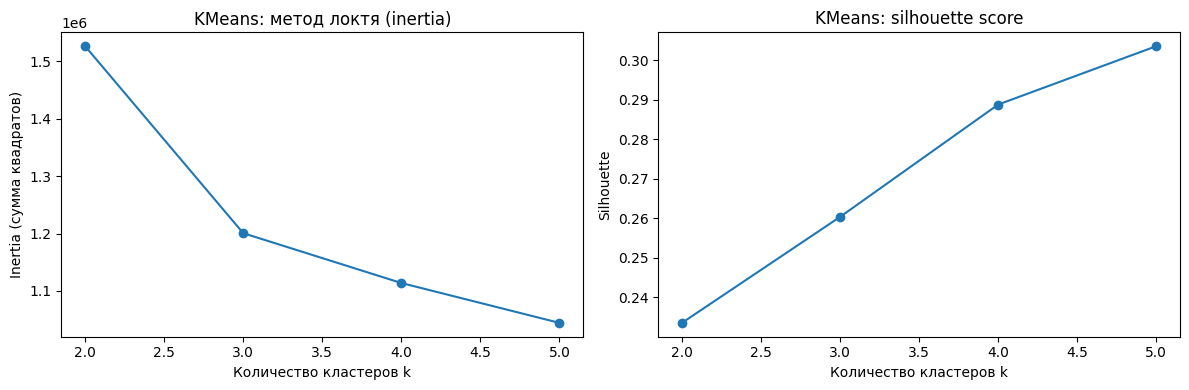

In [154]:
plt.figure(figsize=(12, 4))

# ---- Локоть по inertia ----
plt.subplot(1, 2, 1)
plt.plot(df_kmeans_metrics["k"], df_kmeans_metrics["inertia"], marker="o")
plt.title("KMeans: метод локтя (inertia)")
plt.xlabel("Количество кластеров k")
plt.ylabel("Inertia (сумма квадратов)")

# ---- Silhouette ----
plt.subplot(1, 2, 2)
plt.plot(df_kmeans_metrics["k"], df_kmeans_metrics["silhouette"], marker="o")
plt.title("KMeans: silhouette score")
plt.xlabel("Количество кластеров k")
plt.ylabel("Silhouette")

plt.tight_layout()
plt.show()

Спроецируем класетры на двумерной плоскости

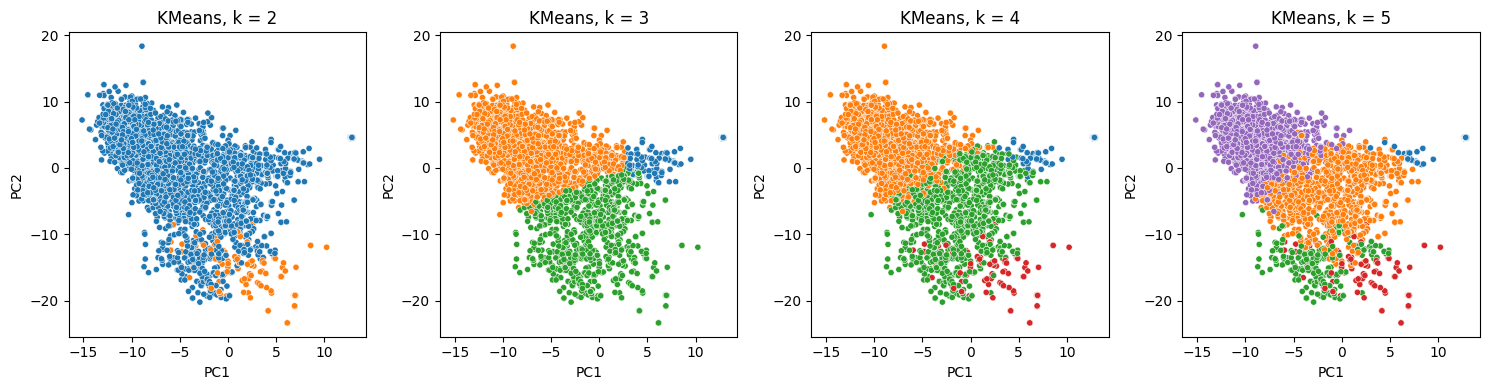

In [155]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=df_clust_kmeans.index
)

plt.figure(figsize=(15, 4))

for i, k in enumerate(k_means_values, start=1):
    plt.subplot(1, len(k_means_values), i)
    labels = labels_dict[k]
    df_pca[f"cluster_k{k}"] = labels

    sns.scatterplot(
        data=df_pca,
        x="PC1",
        y="PC2",
        hue=f"cluster_k{k}",
        palette="tab10",
        s=20,
        legend=False
    )
    plt.title(f"KMeans, k = {k}")

plt.tight_layout()
plt.show()

Выведем информацию для необходимой кластеризации

In [156]:
print_cluster_summary(df_clust_kmeans, "cluster_k3", details=0, bin_threshold=0.15)

=== РАЗМЕРЫ КЛАСТЕРОВ ===
cluster_k3
0    1200
1    1963
2    1046
Всего объектов: 4209

=== ЧИСЛОВЫЕ ПРИЗНАКИ (средние по кластерам) ===
(Порог для бинарных признаков: 0.15. Скрыто 27 малоконтрастных бинарных столбцов.)
cluster_k3                                                                    0        1        2
срок_годности                                                            29.291   29.532   25.170
год_регистрации                                                        2019.953 2017.428 2019.209
количество_групп_компонентов                                              1.464    2.103    1.690
пищевые_вещества_витамины_витаминоподобные_вещества_и_коферменты          0.636    0.400    0.404
пищевые_вещества_макро_и_микроэлементы                                    0.466    0.231    0.202
пищевые_вещества_жиры_жироподобные_вещества_и_их_производные              0.013    0.036    0.300
минорные_компоненты_растений_фенольные_соединения                         0.055    0.663    0

## Иерархическая кластеризация

In [157]:
df_clust_hc = df_clust.copy()

In [158]:
k_values = [2, 3, 4, 5]
hc_results = []
hc_labels_dict = {}

for k in k_values:
    hc = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"  # ward = минимизация внутрикластерной дисперсии
    )
    labels = hc.fit_predict(X)

    hc_labels_dict[k] = labels
    df_clust_hc[f"cluster_hc{k}"] = labels

    sil = silhouette_score(X, labels)
    hc_results.append({"k": k, "silhouette": sil})

df_hc_metrics = pd.DataFrame(hc_results)
print(df_hc_metrics)

   k  silhouette
0  2    0.204539
1  3    0.247250
2  4    0.275015
3  5    0.291924


Построим дендрограмму для визуального анализа вложенности кластеров

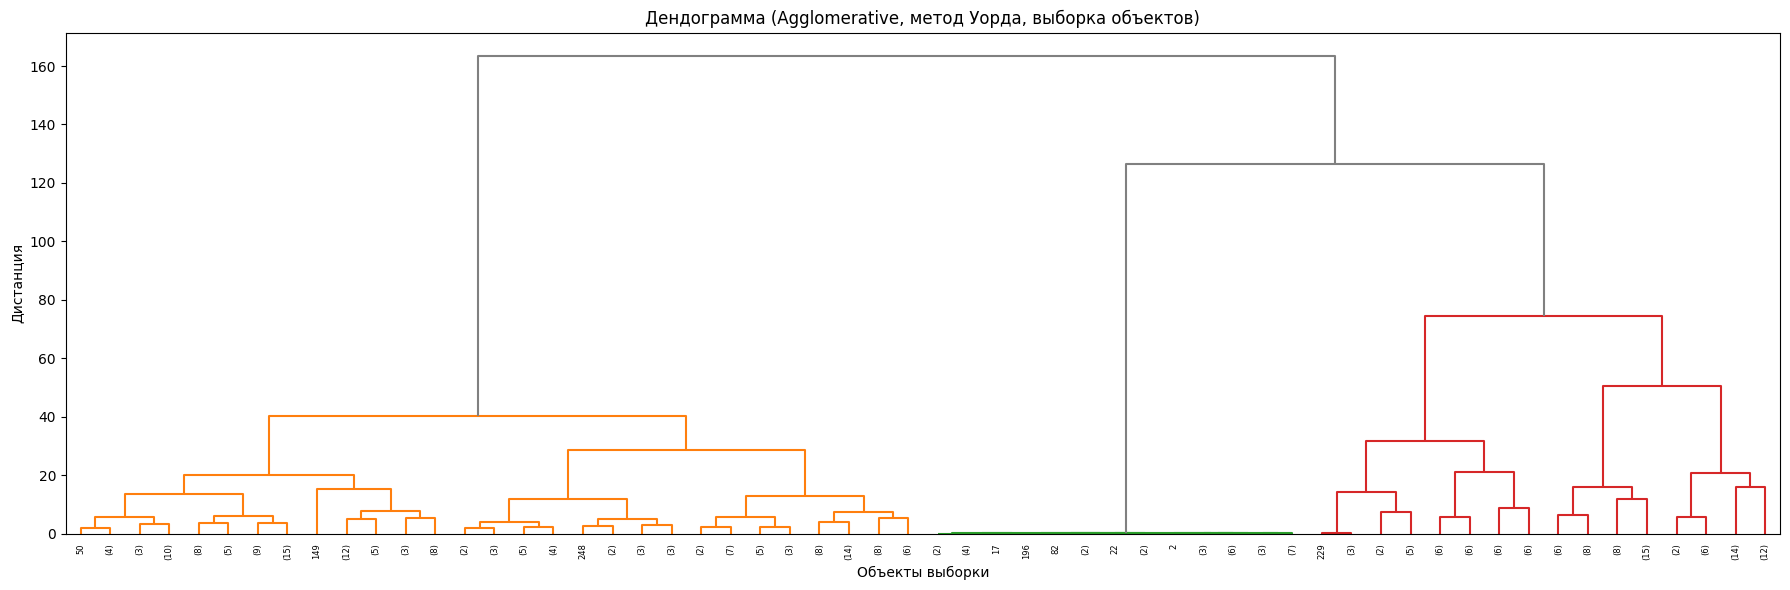

In [159]:
sample_size = min(300, X_pca.shape[0])  # при большем n дендрограмма становится нечитаемой
X_sample = X_pca[:sample_size]

Z = linkage(X_sample, method="ward")

plt.figure(figsize=(18, 6))
dendrogram(
    Z,
    truncate_mode="level",  # обрезаем дерево по уровню, чтобы не было каши
    p=5,                     # число отображаемых уровней
    color_threshold=None,
    above_threshold_color="grey"
)
plt.title("Дендограмма (Agglomerative, метод Уорда, выборка объектов)")
plt.xlabel("Объекты выборки")
plt.ylabel("Дистанция")
plt.tight_layout()
plt.show()

Спроецируем результаты агломеративной кластеризации на плоскость главных компонент

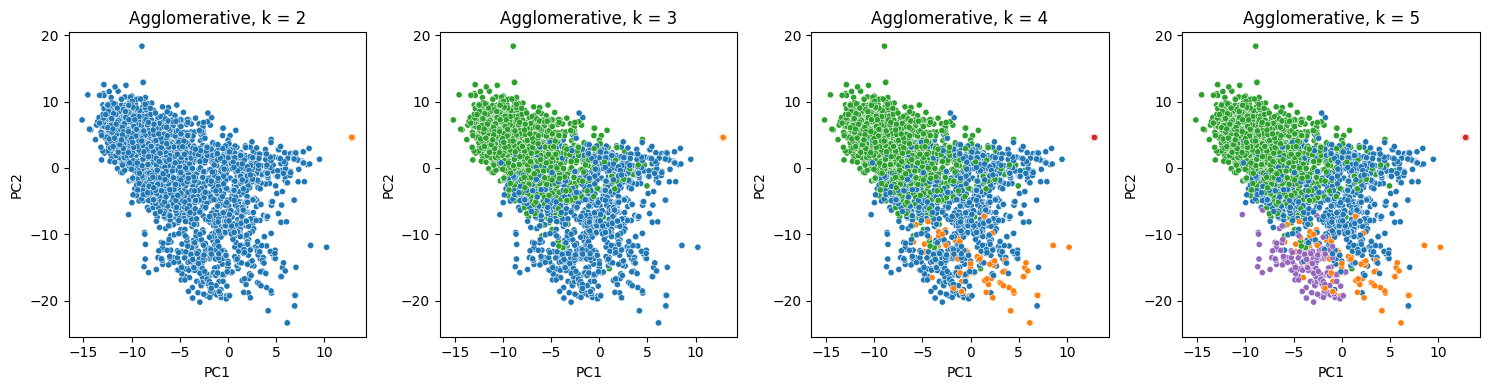

In [160]:
df_pca_hc = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=df_clust_hc.index
)

plt.figure(figsize=(15, 4))

for i, k in enumerate(k_values, start=1):
    plt.subplot(1, len(k_values), i)
    labels = hc_labels_dict[k]
    df_pca_hc[f"cluster_hc{k}"] = labels

    sns.scatterplot(
        data=df_pca_hc,
        x="PC1",
        y="PC2",
        hue=f"cluster_hc{k}",
        palette="tab10",
        s=20,
        legend=False
    )
    plt.title(f"Agglomerative, k = {k}")

plt.tight_layout()
plt.show()

In [161]:
print_cluster_summary(df_clust_hc, "cluster_hc3", details=0, bin_threshold=0.15)

=== РАЗМЕРЫ КЛАСТЕРОВ ===
cluster_hc3
0    1386
1    1070
2    1753
Всего объектов: 4209

=== ЧИСЛОВЫЕ ПРИЗНАКИ (средние по кластерам) ===
(Порог для бинарных признаков: 0.15. Скрыто 27 малоконтрастных бинарных столбцов.)
cluster_hc3                                                             0        1        2
срок_годности                                                      26.443   29.154   29.437
год_регистрации                                                  2018.883 2020.138 2017.415
количество_групп_компонентов                                        1.754    1.442    2.099
пищевые_вещества_витамины_витаминоподобные_вещества_и_коферменты    0.416    0.667    0.388
пищевые_вещества_макро_и_микроэлементы                              0.217    0.490    0.228
пищевые_вещества_жиры_жироподобные_вещества_и_их_производные        0.245    0.012    0.026
минорные_компоненты_растений_фенольные_соединения                   0.197    0.016    0.679
пищевые_вещества_углеводы_и_продукты_их_пе

## DBSCAN

Сначала построим k-distance график, чтобы примерно оценить разумное значение eps

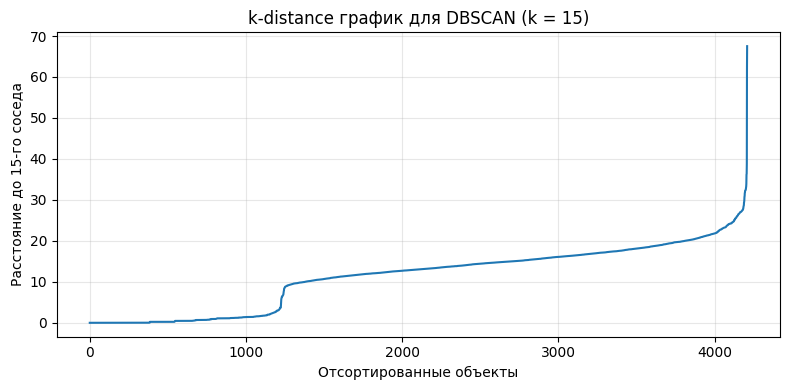

In [162]:
df_clust_dbscan = df_clust.copy()

min_samples = 15 # поэксперементировать

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.title(f"k-distance график для DBSCAN (k = {min_samples})")
plt.xlabel("Отсортированные объекты")
plt.ylabel(f"Расстояние до {min_samples}-го соседа")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [163]:
eps = 12 # поэксперементировать

dbscan = DBSCAN(
    eps=eps,
    min_samples=min_samples,
    metric="euclidean",
    n_jobs=-1
)

db_labels = dbscan.fit_predict(X)

df_clust_dbscan["cluster_dbscan"] = db_labels

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = np.sum(db_labels == -1)

print(f"DBSCAN: eps = {eps}, min_samples = {min_samples}")
print(f"Количество кластеров (без шума): {n_clusters}")
print(f"Количество объектов, помеченных как шум (-1): {n_noise}")

# Silhouette считаем только по точкам, которые попали в кластеры (без шума)
mask_core = db_labels != -1

if n_clusters > 1 and mask_core.sum() > 0:
    sil_db = silhouette_score(X[mask_core], db_labels[mask_core])
    print(f"Silhouette-score (без шума): {sil_db:.4f}")
else:
    print("Silhouette-score не считается: найден менее чем 2 кластера или почти всё шум.")

DBSCAN: eps = 12, min_samples = 15
Количество кластеров (без шума): 8
Количество объектов, помеченных как шум (-1): 1978
Silhouette-score (без шума): 0.3288


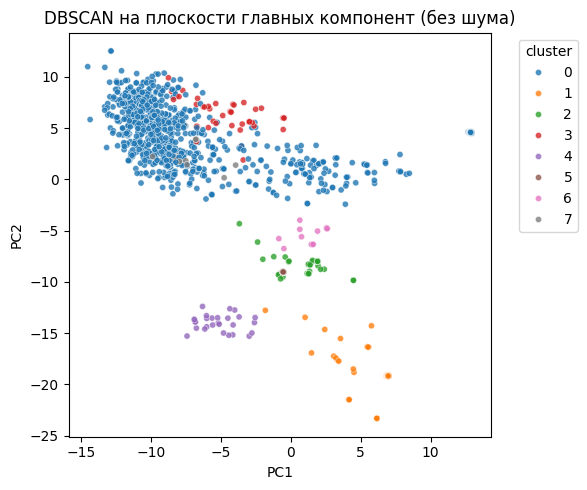

In [164]:
mask = db_labels != -1

if mask.sum() == 0:
    print("DBSCAN пометил все объекты как шум, кластеров нет.")
else:
    df_pca_db = pd.DataFrame({
        "PC1": X_pca[mask, 0],
        "PC2": X_pca[mask, 1],
        "cluster": db_labels[mask]
    })

    plt.figure(figsize=(6, 5))
    sns.scatterplot(
        data=df_pca_db,
        x="PC1",
        y="PC2",
        hue="cluster",
        palette="tab10",
        s=20,
        alpha=0.8
    )
    plt.title("DBSCAN на плоскости главных компонент (без шума)")
    plt.legend(title="cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [165]:
df_db_non_noise = df_clust_dbscan[df_clust_dbscan["cluster_dbscan"] != -1].copy()

if not df_db_non_noise.empty and n_clusters > 0:
    print_cluster_summary(df_db_non_noise, "cluster_dbscan", details=0, bin_threshold=0.15)
else:
    print("DBSCAN пометил почти все объекты как шум — стоит подобрать другие eps / min_samples.")

=== РАЗМЕРЫ КЛАСТЕРОВ ===
cluster_dbscan
0    1901
1     144
2      35
3      48
4      28
5      35
6      20
7      20
Всего объектов: 2231

=== ЧИСЛОВЫЕ ПРИЗНАКИ (средние по кластерам) ===
(Порог для бинарных признаков: 0.15. Скрыто 15 малоконтрастных бинарных столбцов.)
cluster_dbscan                                                                        0        1        2        3        4        5        6        7
происхождение                                                                     0.608    0.667    0.686    0.875    0.464    1.000    0.450    0.750
срок_годности                                                                    29.322   25.438   30.171   28.500   23.036   12.343   28.800   29.400
год_регистрации                                                                2018.956 2019.931 2018.857 2018.667 2018.286 2019.086 2021.050 2019.150
количество_групп_компонентов                                                      1.771    1.514    2.143    1.500    1.5

Интерактивное представление матрицы корелляции

In [166]:
# Определяем ключевые слова для поиска
y_keywords = ['пищевые_вещества', 'минорные_компоненты', 'пробиотики', 'минеральные']
x_keywords = ['система_органов', 'группы_населения', 'количество_групп_компонентов']

# Функция для фильтрации с созданием прямоугольной матрицы
def create_rectangular_correlation_matrix(corr_matrix, y_keywords, x_keywords):
    """Создает прямоугольную корреляционную матрицу между разными группами признаков."""

    # Преобразуем все к нижнему регистру для унификации
    y_keywords_lower = [kw.lower() for kw in y_keywords]
    x_keywords_lower = [kw.lower() for kw in x_keywords]

    # Получаем признаки для оси Y (будут строками матрицы)
    y_features = []
    for feature in corr_matrix.columns:
        feature_lower = str(feature).lower()
        if any(keyword in feature_lower for keyword in y_keywords_lower):
            y_features.append(feature)

    print(f"Найдено признаков для оси Y: {len(y_features)}")
    if y_features:
        print("Примеры признаков оси Y:", y_features[:5])

    # Получаем признаки для оси X (будут столбцами матрицы)
    x_features = []
    for feature in corr_matrix.columns:
        feature_lower = str(feature).lower()
        if any(keyword in feature_lower for keyword in x_keywords_lower):
            x_features.append(feature)

    print(f"Найдено признаков для оси X: {len(x_features)}")
    if x_features:
        print("Примеры признаков оси X:", x_features[:5])

    # Создаем прямоугольную матрицу корреляции
    if y_features and x_features:
        # Используем loc для выбора строк (Y) и столбцов (X)
        rectangular_matrix = corr_matrix.loc[y_features, x_features]
        return rectangular_matrix
    else:
        print("Не удалось создать прямоугольную матрицу - отсутствуют признаки для одной из осей")
        return pd.DataFrame()

Найдено признаков для оси Y: 15
Примеры признаков оси Y: ['пищевые_вещества_витамины_витаминоподобные_вещества_и_коферменты', 'пищевые_вещества_макро_и_микроэлементы', 'пищевые_вещества_жиры_жироподобные_вещества_и_их_производные', 'пищевые_вещества_белки_пептиды_аминокислоты_нуклеиновые_кислоты', 'минорные_компоненты_растений_фенольные_соединения']
Найдено признаков для оси X: 15
Примеры признаков оси X: ['количество_групп_компонентов', 'система_органов_для_беременных_кормящих_и_планирующих_беременность', 'система_органов_костно_мышечная_система', 'система_органов_нервная_система', 'система_органов_иммунная_система']


<Axes: >

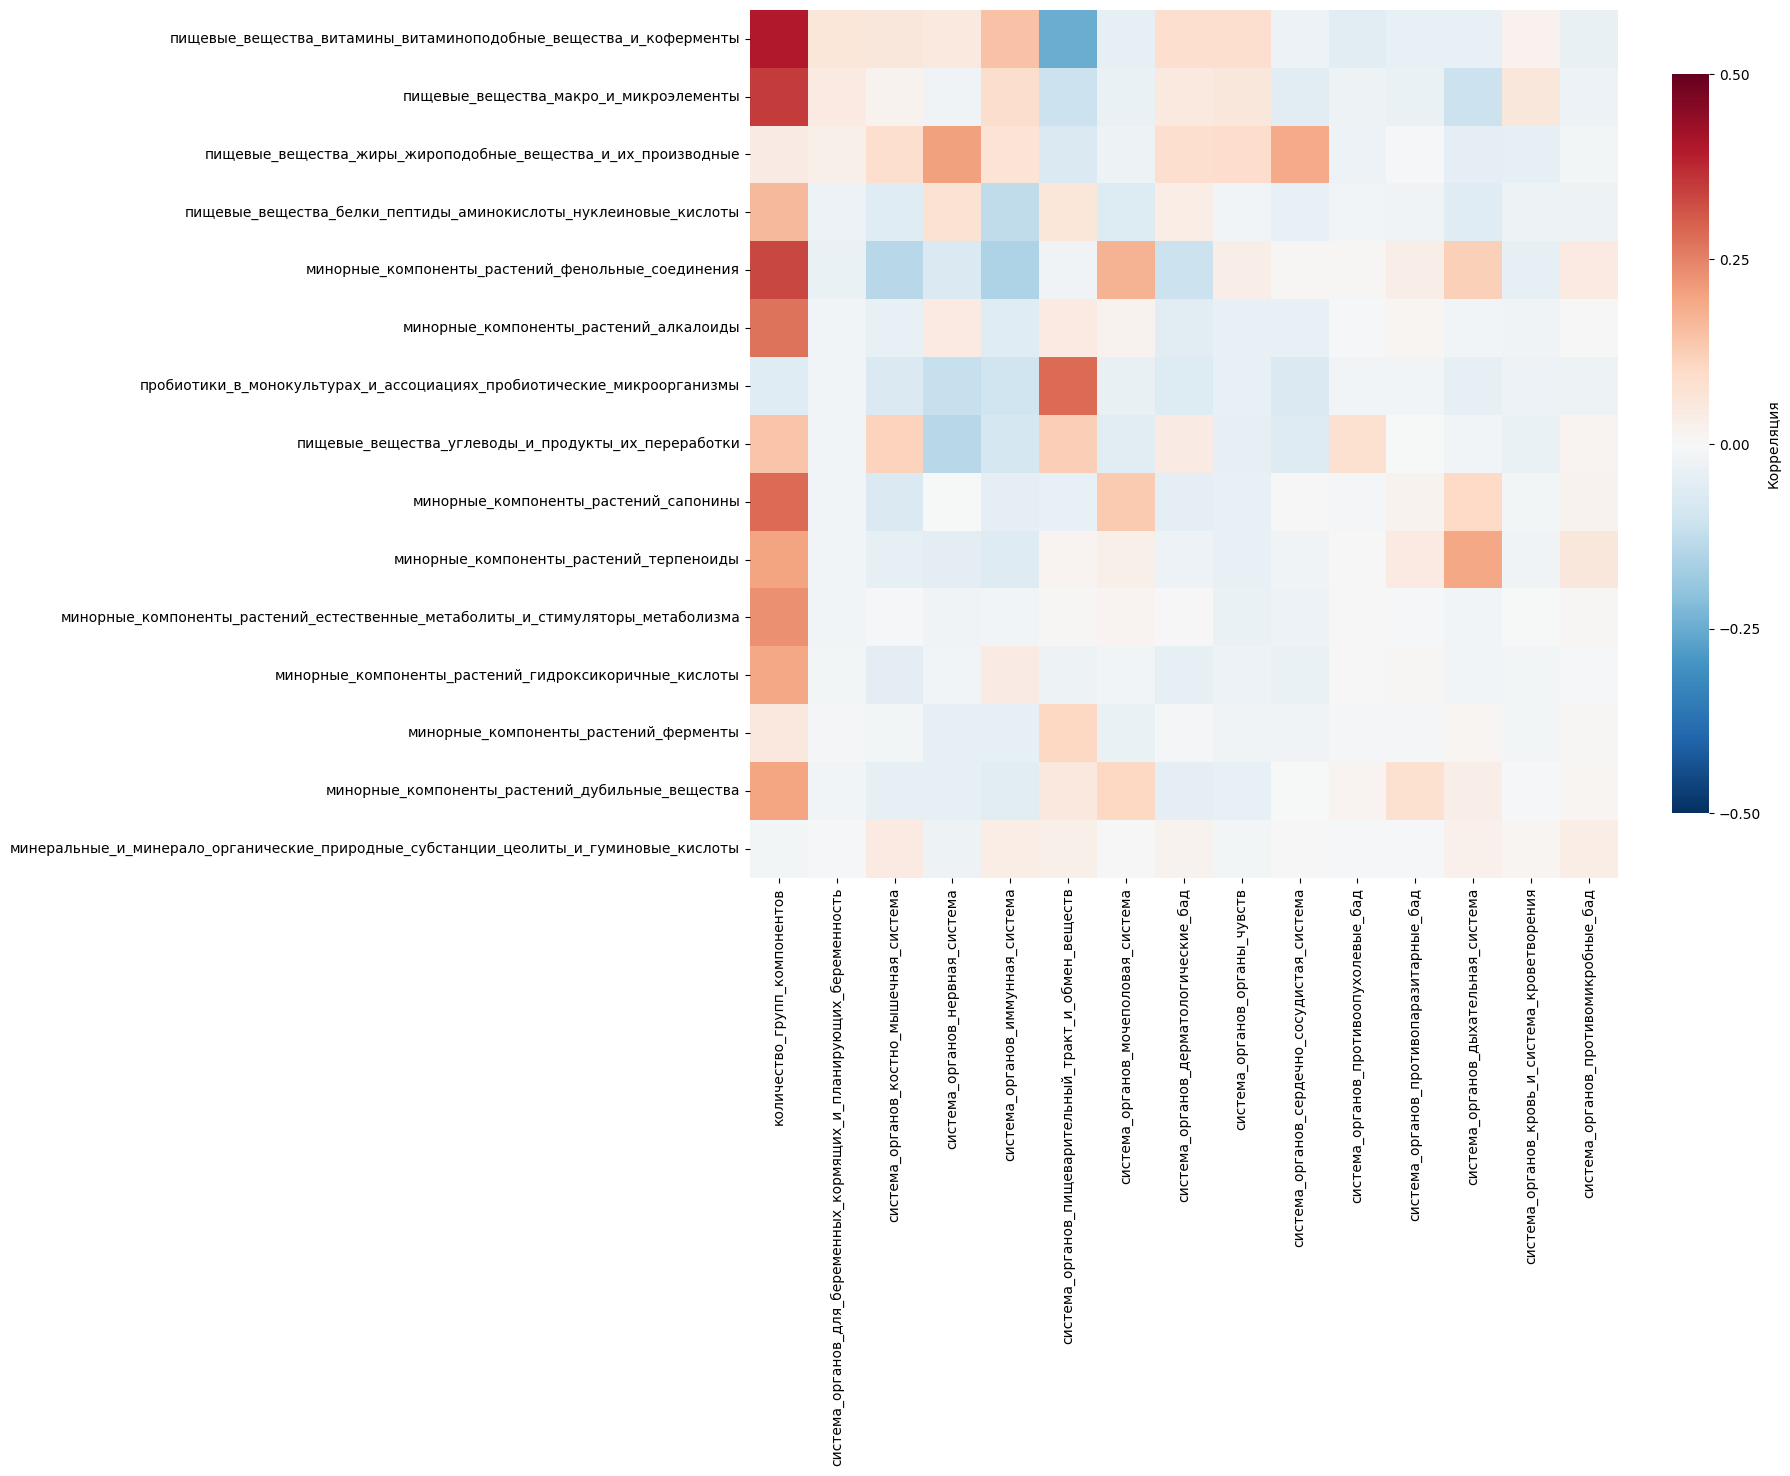

In [167]:
pearson = create_rectangular_correlation_matrix(correlation_pearson, y_keywords, x_keywords)
plt.figure(figsize=(14, 12))
sns.heatmap(
    pearson,
    cmap='RdBu_r',
    center=0,
    vmin=-0.5, vmax=0.5,
    square=True,
    cbar_kws={
        'label': 'Корреляция',
        'shrink': 0.8,
        'ticks': [-0.5, -0.25, 0, 0.25, 0.5]
    }
)

In [188]:
import plotly.graph_objects as go
import pandas as pd
import re

def create_rectangular_heatmap_html(
    corr_matrix,
    title: str,
    output_filename: str,
    y_label: str = "Признаки (Y)",
    x_label: str = "Признаки (X)",
    cell_size_px: int = 75,
    min_dimension_px: int = 1000,
):
    num_rows, num_cols = corr_matrix.shape

    dynamic_height = max(min_dimension_px, num_rows * cell_size_px + 300)
    dynamic_width = max(min_dimension_px, num_cols * cell_size_px + 400)

    fig = go.Figure(data=go.Heatmap(
        z=corr_matrix.values,
        x=corr_matrix.columns,
        y=corr_matrix.index,
        colorscale='RdBu_r',
        zmin=-1.0,
        zmax=1.0,
        hoverongaps=False,
        hovertemplate='X: %{x}<br>Y: %{y}<br>Корреляция: %{z:.3f}<extra></extra>',
        colorbar=dict(
            title="Корреляция",
            titleside="right",
            thickness=25,
            len=0.8,
            tickfont=dict(size=11)
        )
    ))

    fig.update_layout(
        title=dict(text=title, x=0.5, xanchor='center', font=dict(size=18)),
        xaxis_title=x_label,
        yaxis_title=y_label,
        xaxis=dict(
            tickangle=-90,
            automargin=True,
            tickfont=dict(size=10),
            showspikes=True,
            spikemode='across',
            spikesnap='cursor',
            spikethickness=1,
            spikecolor="rgba(100,100,100,0.7)"
        ),
        yaxis=dict(
            autorange="reversed",
            automargin=True,
            tickfont=dict(size=10),
            showspikes=True,
            spikemode='across',
            spikesnap='cursor',
            spikethickness=1,
            spikecolor="rgba(100,100,100,0.7)"
        ),
        autosize=False,
        width=dynamic_width,
        height=dynamic_height,
        margin=dict(l=200, r=150, t=140, b=200),
        plot_bgcolor='rgba(0,0,0,0)',
        hovermode='closest'
    )

    config = {
        'displaylogo': False,
        'displayModeBar': True,
        'toImageButtonOptions': {
            'format': 'svg',
            'filename': output_filename.replace('.html', ''),
            'height': dynamic_height,
            'width': dynamic_width,
            'scale': 2
        }
    }

    # Сохраняем HTML
    fig.write_html(
        output_filename,
        auto_open=False,
        config=config,
        include_plotlyjs='cdn'
    )

    # Словарь перевода стандартных кнопок Plotly
    translations = {
        "Download plot": "Скачать",
        "Zoom": "Увеличить",
        "Pan": "Переместить",
        "Zoom in": "Приблизить",
        "Zoom out": "Отдалить",
        "Autoscale": "Авто масштаб",
        "Reset axes": "Сбросить оси",
    }

    # Читаем файл, добавляем скрипт перевода
    with open(output_filename, 'r', encoding='utf-8') as f:
        html_content = f.read()

    # Создаём JS-скрипт для замены текста кнопок после загрузки
    js_script = """
    <script>
    function translatePlotlyButtons() {
        const translations = """ + str(translations).replace("'", '"') + """;
        for (let key in translations) {
            let elements = document.body.querySelectorAll('[data-title="' + key + '"]');
            elements.forEach(el => {
                el.setAttribute('data-title', translations[key]);
                if (el.hasAttribute('aria-label')) {
                    el.setAttribute('aria-label', translations[key]);
                }
                // Иногда подсказка в тултипе
                let tooltip = el.querySelector('title');
                if (tooltip && tooltip.textContent === key) {
                    tooltip.textContent = translations[key];
                }
            });
        }
        // Также переводим всплывающие подсказки (title)
        document.querySelectorAll('[title]').forEach(el => {
            if (translations[el.title]) {
                el.title = translations[el.title];
            }
        });
    }

    // Запускаем перевод после полной загрузки страницы и графика
    if (document.readyState === 'loading') {
        document.addEventListener('DOMContentLoaded', translatePlotlyButtons);
    } else {
        translatePlotlyButtons();
    }

    // Также пытаемся отловить момент, когда Plotly добавит кнопки (асинхронно)
    const observer = new MutationObserver(translatePlotlyButtons);
    observer.observe(document.body, { childList: true, subtree: true });
    </script>
    """

    # Вставляем скрипт перед закрывающим
    html_content = html_content.replace('</body>', js_script + '</body>')

    with open(output_filename, 'w', encoding='utf-8') as f:
        f.write(html_content)

    print(f"Интерактивная тепловая карта сохранена в {output_filename} "
          f"(размер: {dynamic_width}×{dynamic_height})")

def format_labels_for_plot(labels):
    res = []
    for lbl in labels:
        # Заменяем подчёркивания на пробелы
        clean_label = lbl.replace('_', ' ')
        # Делаем жирным через HTML-тег
        res.append(f'<b>{clean_label}</b>')
    return res

# === Пирсон ===
pears = create_rectangular_correlation_matrix(correlation_pearson, y_keywords, x_keywords)
pears.columns = format_labels_for_plot(pears.columns.tolist())
pears.index = format_labels_for_plot(pears.index.tolist())
create_rectangular_heatmap_html(
    pears,
    'Интерактивная корреляция Пирсона (линейная)',
    'interactive_pearson_heatmap.html',
    cell_size_px=85  # чуть больше для читаемости
)

# === Спирман ===
spearm = create_rectangular_correlation_matrix(correlation_spearman, y_keywords, x_keywords)
spearm.columns = format_labels_for_plot(spearm.columns.tolist())
spearm.index = format_labels_for_plot(spearm.index.tolist())
create_rectangular_heatmap_html(
    spearm,
    'Интерактивная корреляция Спирмана (ранговая)',
    'interactive_spearman_heatmap.html',
    cell_size_px=85
)

Найдено признаков для оси Y: 15
Примеры признаков оси Y: ['пищевые_вещества_витамины_витаминоподобные_вещества_и_коферменты', 'пищевые_вещества_макро_и_микроэлементы', 'пищевые_вещества_жиры_жироподобные_вещества_и_их_производные', 'пищевые_вещества_белки_пептиды_аминокислоты_нуклеиновые_кислоты', 'минорные_компоненты_растений_фенольные_соединения']
Найдено признаков для оси X: 15
Примеры признаков оси X: ['количество_групп_компонентов', 'система_органов_для_беременных_кормящих_и_планирующих_беременность', 'система_органов_костно_мышечная_система', 'система_органов_нервная_система', 'система_органов_иммунная_система']
Интерактивная тепловая карта сохранена в interactive_pearson_heatmap.html (размер: 1675×1575)
Найдено признаков для оси Y: 15
Примеры признаков оси Y: ['пищевые_вещества_витамины_витаминоподобные_вещества_и_коферменты', 'пищевые_вещества_макро_и_микроэлементы', 'пищевые_вещества_жиры_жироподобные_вещества_и_их_производные', 'пищевые_вещества_белки_пептиды_аминокислоты_нук

# Сохранение изменений

In [191]:
try:
    _system = get_ipython().system
except NameError:
    def _system(cmd):
        return subprocess.check_call(cmd, shell=True)

IN_COLAB = False
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if not IN_COLAB:
    print("Окружение не Colab. Настройка на безопасную версию")
    NOTEBOOK = "3311_bajmuhamedov_arshin_pasechny_practice_bad.ipynb"
    cfg_path = ".jupytext.toml"
else:
    print("Running in Colab, executing Jupytext sync logic...")

    from google.colab import drive
    drive.mount('/content/drive')

    NOTEBOOK = "/content/drive/MyDrive/Colab Notebooks/3311_bajmuhamedov_arshin_pasechny_practice_bad.ipynb"
    cfg_path = "/content/.jupytext.toml"

_system(f'pip -q install jupytext nbstripout')
_system(f'nbstripout "{NOTEBOOK}"')

cfg = '''formats = "ipynb,py:percent"
cell_metadata_filter = "-all,tags"
notebook_metadata_filter = "kernelspec,jupytext"
'''
with open(cfg_path, "w", encoding="utf-8") as f:
    f.write(cfg)

if IN_COLAB:
    ipynb_path = Path(NOTEBOOK)
    py_path = ipynb_path.with_suffix(".py")

    if not ipynb_path.exists():
        raise FileNotFoundError(f"Не найден .ipynb: {ipynb_path}")

    print("IPYNB:", ipynb_path)
    print("PY:", py_path)

    _system(f'nbstripout "{NOTEBOOK}"')

    if py_path.exists():
        py_path.unlink()

    _system(f'jupytext --to py:percent "{NOTEBOOK}"')

    import datetime
    stat = py_path.stat()
    print("\nОбновлён .py:", py_path)

else:
    pass

Running in Colab, executing Jupytext sync logic...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
IPYNB: /content/drive/MyDrive/Colab Notebooks/3311_bajmuhamedov_arshin_pasechny_practice_bad.ipynb
PY: /content/drive/MyDrive/Colab Notebooks/3311_bajmuhamedov_arshin_pasechny_practice_bad.py
[jupytext] Reading /content/drive/MyDrive/Colab Notebooks/3311_bajmuhamedov_arshin_pasechny_practice_bad.ipynb in format ipynb
[jupytext] Writing '/content/drive/MyDrive/Colab Notebooks/3311_bajmuhamedov_arshin_pasechny_practice_bad.py' in format py:percent

Обновлён .py: /content/drive/MyDrive/Colab Notebooks/3311_bajmuhamedov_arshin_pasechny_practice_bad.py
